# Import of libraries


In [1]:
# pandas
import pandas as pd

# numpy
import numpy as np

# sklearn
import sklearn

# math
import math

#seaborn
import seaborn as sns

# sklearn (pre)processing & pipeline
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

#sklearn metrics & curves
from sklearn.metrics import  recall_score, precision_score, precision_recall_curve, roc_curve, roc_auc_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

#Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

#sklearn Classifier models
from sklearn.linear_model import LogisticRegression     #LogisticRegression
from sklearn.neighbors import KNeighborsClassifier      #Nearest Neighbor
from sklearn.ensemble import RandomForestClassifier     #Random Forest
from sklearn.ensemble import GradientBoostingClassifier #Gradient Boosting

#mathplot
import matplotlib.pyplot as plt


# Functions for Cost Based Thresholding

In [2]:
def binary_clf_curve(y_true, y_score):
    
    #make Numpy arrays from pd.Series
    if isinstance(y_true, pd.Series):
        y_true = y_true.to_numpy()

    if isinstance(y_score, pd.Series):
        y_score = y_score.to_numpy()
    
    # sort scores and corresponding truth values
    desc_score_indices = np.argsort(y_score, kind="mergesort")[::-1]
    y_score = y_score[desc_score_indices]
    y_true = y_true[desc_score_indices]
    
    # y_score typically has many tied values. Here we extract
    # the indices associated with the distinct values. We also
    # concatenate a value for the end of the curve.
    distinct_value_indices = np.where(np.diff(y_score))[0]
    threshold_idxs = np.r_[distinct_value_indices, y_true.size - 1]

    # accumulate the true positives with decreasing threshold
    tps = np.cumsum(y_true)[threshold_idxs]
    
    fps = 1 + threshold_idxs - tps
    fns = tps[-1] - tps
    thresholds = y_score[threshold_idxs]
    return tps, fps, fns, thresholds

In [3]:
# Function to illustrates the process of Empirical Cost-Based Thresholding
def empirical_costbased_thresholding(y_true, scores, model_name, C_FP, C_FN, p=False):
    """
    Illustrates Empirical Cost-Based Thresholding

    Parameters
    ----------
    scores : ndarray of shape (n_samples,)
        Predicted scores for all samples (e.g. classifier outputs or probabilities).
    model_name : str
        Name of the model, used for labeling or output purposes.
    C_FP : int or float
        Cost associated with a false positive classification.
    C_FN : int or float
        Cost associated with a false negative classification.
    p : bool, optional (default=False)
        If True, the scores are probability-like and range from 0 to 1.
        and will be compared with the theoretical 
    """
    
    
    true_positives, false_positives,  false_negatives, thresholds = binary_clf_curve(y_true, scores)
    
    total_costs = C_FP * false_positives + C_FN * false_negatives  
    
    plt.figure()
    
    plt.plot(thresholds, total_costs, marker='o',color='blue' , linestyle='-')
    plt.plot(thresholds, total_costs,  linestyle='-',color='blue', linewidth=4, label= 'Total Expected Cost')
    
    
    if(p):
        plt.xlabel("Probability Threshold")
    else:
        plt.xlabel("Threshold")
    plt.ylabel("Cost")
    plt.title(f"Cost vs. Threshold - {model_name}")
    
    min_cost_index = np.argmin(total_costs)
    optimal_threshold = thresholds[min_cost_index]
    
    plt.axvline(optimal_threshold, color='r', linestyle='--', label=f'Optimal Threshold: {optimal_threshold:.2f}')
    plt.legend()
    plt.show()
    
    TP = true_positives[min_cost_index]
    FP = false_positives[min_cost_index]
    FN = false_negatives[min_cost_index]
    precision = TP/(TP+FP)
    recall = TP/(TP+FN)
                    
    
    threshold_with_calibrated_p = C_FP/(C_FN+C_FP)
    print(f"Optimal threshold for {model_name}: {optimal_threshold:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"Empirically minimized expected costs: {total_costs[min_cost_index]:.2f}")
    print(f"Empirically minimized expected costs per item: {total_costs[min_cost_index]/len(y_true):.2f}")
    
    if(p):
        print(" ")
        print(f"With calibrated p threshold would be: {threshold_with_calibrated_p:.2f}")
        index = np.searchsorted(-thresholds, -threshold_with_calibrated_p, side='right') - 1
        print(f"Expected cost with this calibrated p threshold: {total_costs[index]:.2f}")    
    
    return optimal_threshold

In [4]:
# Function to calculate the average cost
def myAveragedCosts(y_true, y_pred, C_FP, C_FN):
    score = confusion_matrix(y_true, y_pred)[1,0]*C_FN + confusion_matrix(y_true, y_pred)[0,1]*C_FP 
    return score/len(y_true)

# Function for evaluating a model, using scores & curves

In [5]:
#Function to print scores and curves
def evaluateModel(y_true, y_proba, model, set):
    # Scores
    precision = precision_score(y_true, y_proba[:,1].round())
    recall = recall_score(y_true, y_proba[:,1].round())
    f1 = f1_score(y_true, y_proba[:,1].round())
    auc_score = roc_auc_score(y_true, y_proba[:,1])
    
    print(f"{model} Evaluation on {set} set:")
    print(f'Precision: {precision:.3f}')
    print(f"Recall: {recall:.3f}")    
    print(f'F1 Score: {f1:.3f}')
    print(f'AUC: {auc_score:.3f}')
     
    #curves
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba[:,1])

    plt.figure(figsize=(6, 5))

    # recall vs precision
    plt.plot(recalls, precisions, "b-", linewidth=2, label=model + " " + set)
    plt.title("Precision vs Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.axis([0, 1, 0, 1])
    plt.grid()
    plt.legend(loc="lower left")
    plt.show()

    # recall and precision vs thresholds
    plt.plot(thresholds, precisions[:-1], "r-", label=f"Precision {set}", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label=f"Recalls {set}", linewidth=2)
    plt.grid()
    plt.title("Precision & Recall vs Threshold")
    plt.xlabel("Threshold")
    plt.legend(loc="center right")
    plt.show()

    # ROC AUC
    # TPR's & FPR's
    fpr, tpr, _ = roc_curve(y_true, y_proba[:,1])

    #plot the Random Classifier
    plt.plot([0,1], [0,1], 'k:', label = "Random Classifier's ROC Curve")

    #plot the ROC's of the models & the AUC's
    plt.plot(fpr, tpr, "r-", linewidth=2, label=f"ROC {model} on {set} (AUC = {auc_score:.3f})")
    plt.title("ROC AUC")

    #some formatting
    plt.xlabel('False Positive Rate (Fall-Out)')
    plt.ylabel('True Positive Rate (Recall)')
    plt.grid()
    plt.axis([0, 1, 0, 1])
    plt.legend(loc="lower right", fontsize=13)
    plt.show()
    
    return (precision, recall, f1, auc_score)

# Prepare Data

## Description of the data

Variables Table

| Variable Name | Role | Type | Demographic | Description | Units | Missing Values |
|---------------|------|------|-------------|-------------|-------|----------------|
| age           | Feature | Integer | Age | | | no |
| job | Feature | Categorical | Occupation | type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown') | | no |
| marital | Feature | Categorical | Marital Status | marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed) | | no |
| education | Feature | Categorical | Education Level | (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown') | | no |
| default | Feature | Binary | | has credit in default? | | no |
| housing | Feature | Binary | | has housing loan? | | no |
| loan | Feature | Binary | | has personal loan? | | no |
| contact | Feature | Categorical | | contact communication type (categorical: 'cellular','telephone') | | yes |
| day_of_week | Feature | Date | | last contact day of the week | | no |
| month | Feature	 | Date | | last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec') | | no |
| duration | Feature | Integer | | last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model. | | no |
| campaign | Feature | Integer | | number of contacts performed during this campaign and for this client (numeric, includes last contact) | | no |
| pdays | Feature | Integer | | number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted) | | yes |
| previous | Feature | Integer | | number of contacts performed before this campaign and for this client | | no |
| poutcome | Feature | Categorical | | outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success') | | yes |
| emp.var.rate | Feature | float64 | | Employment variation rate, with a quarterly frequency | | no |
| cons.price.idx | Feature | float64 | | Monthly average consumer price index | | no |
| cons.conf.idx | Feature | float64 | | Monthly average consumer confidence index | | no |
| euribor3m | Feature | float64 | | Daily three month Euribor rate | | no |
| nr.employed | Feature | float64 | | Quarterly average of the total number of employed citizens | | no |
| y	| Target | Binary | | has the client subscribed a term deposit? | | |

## Import of Data

In [6]:
# Inladen met de juiste scheidingstekens
# bank_data_small = pd.read_csv('C:/Users/JennyPoelen(Companen/Pythonscripts/bank-additional-full.csv', sep=';')
bank_data_full = pd.read_csv('C:/Users/JennyPoelen(Companen/Pythonscripts/bank-additional-full.csv', sep=';')

In [7]:
average_call_seconds = round(bank_data_full["duration"].mean(), 2)
average_call_minutes = round(average_call_seconds/60, 2)

### Calculate & determine values for Cost Based Thresholding

In [8]:
call_cost_fixed = 15
call_cost_minute = 3
revenue_missed = 100

# False Positive is een onnodig gevoerd gesprek
cost_unsuccesfull_call = call_cost_fixed + (average_call_minutes * call_cost_minute)

# False Negative is een niet gevoerd, maar wel gewenst gesprek
cost_missed_call = revenue_missed
print (f"Kosten onnodig gesprek (FP): {cost_unsuccesfull_call}")
print (f"Kosten gemist gesprek (FN): {cost_missed_call}")

Kosten onnodig gesprek (FP): 27.9
Kosten gemist gesprek (FN): 100


In [9]:
# Based on the Variables Table (see above) the column 'duration' will not be used for predictive purposes
bank_data_full = bank_data_full.drop("duration", axis='columns')

In [10]:
bank_data_full.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [11]:
bank_data_full.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [12]:
bank_data_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

In [13]:
bank_data_full.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [14]:
print("Continuous Variables: ")
continous_vars=bank_data_full.describe().columns  #get the names of numerical variables, in this case continuous variables
print(continous_vars)

print("\nCategorical Variables: ")
categorical_vars=bank_data_full.describe(include=[object]).columns
print(categorical_vars)

Continuous Variables: 
Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

Categorical Variables: 
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')


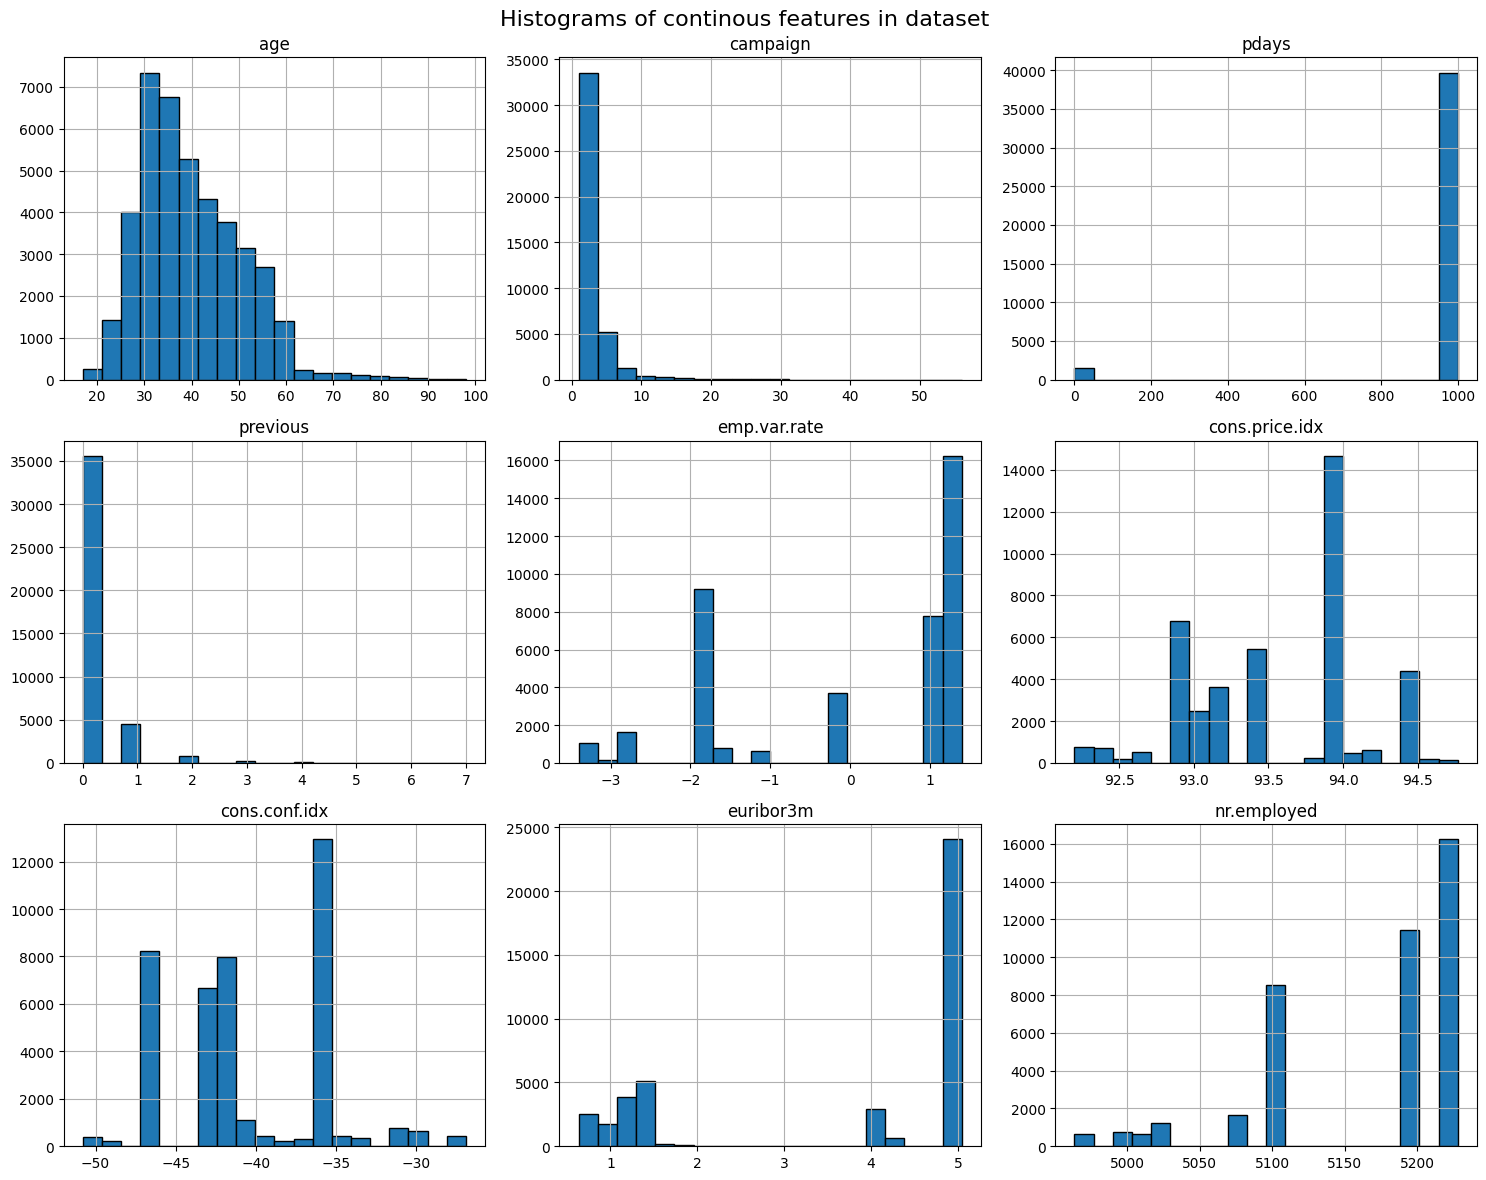

In [15]:
bank_data_full.hist(column=continous_vars, bins=20, figsize=(15, 12), edgecolor="black")
plt.suptitle("Histograms of continous features in dataset", fontsize=16)
plt.tight_layout()
plt.show()

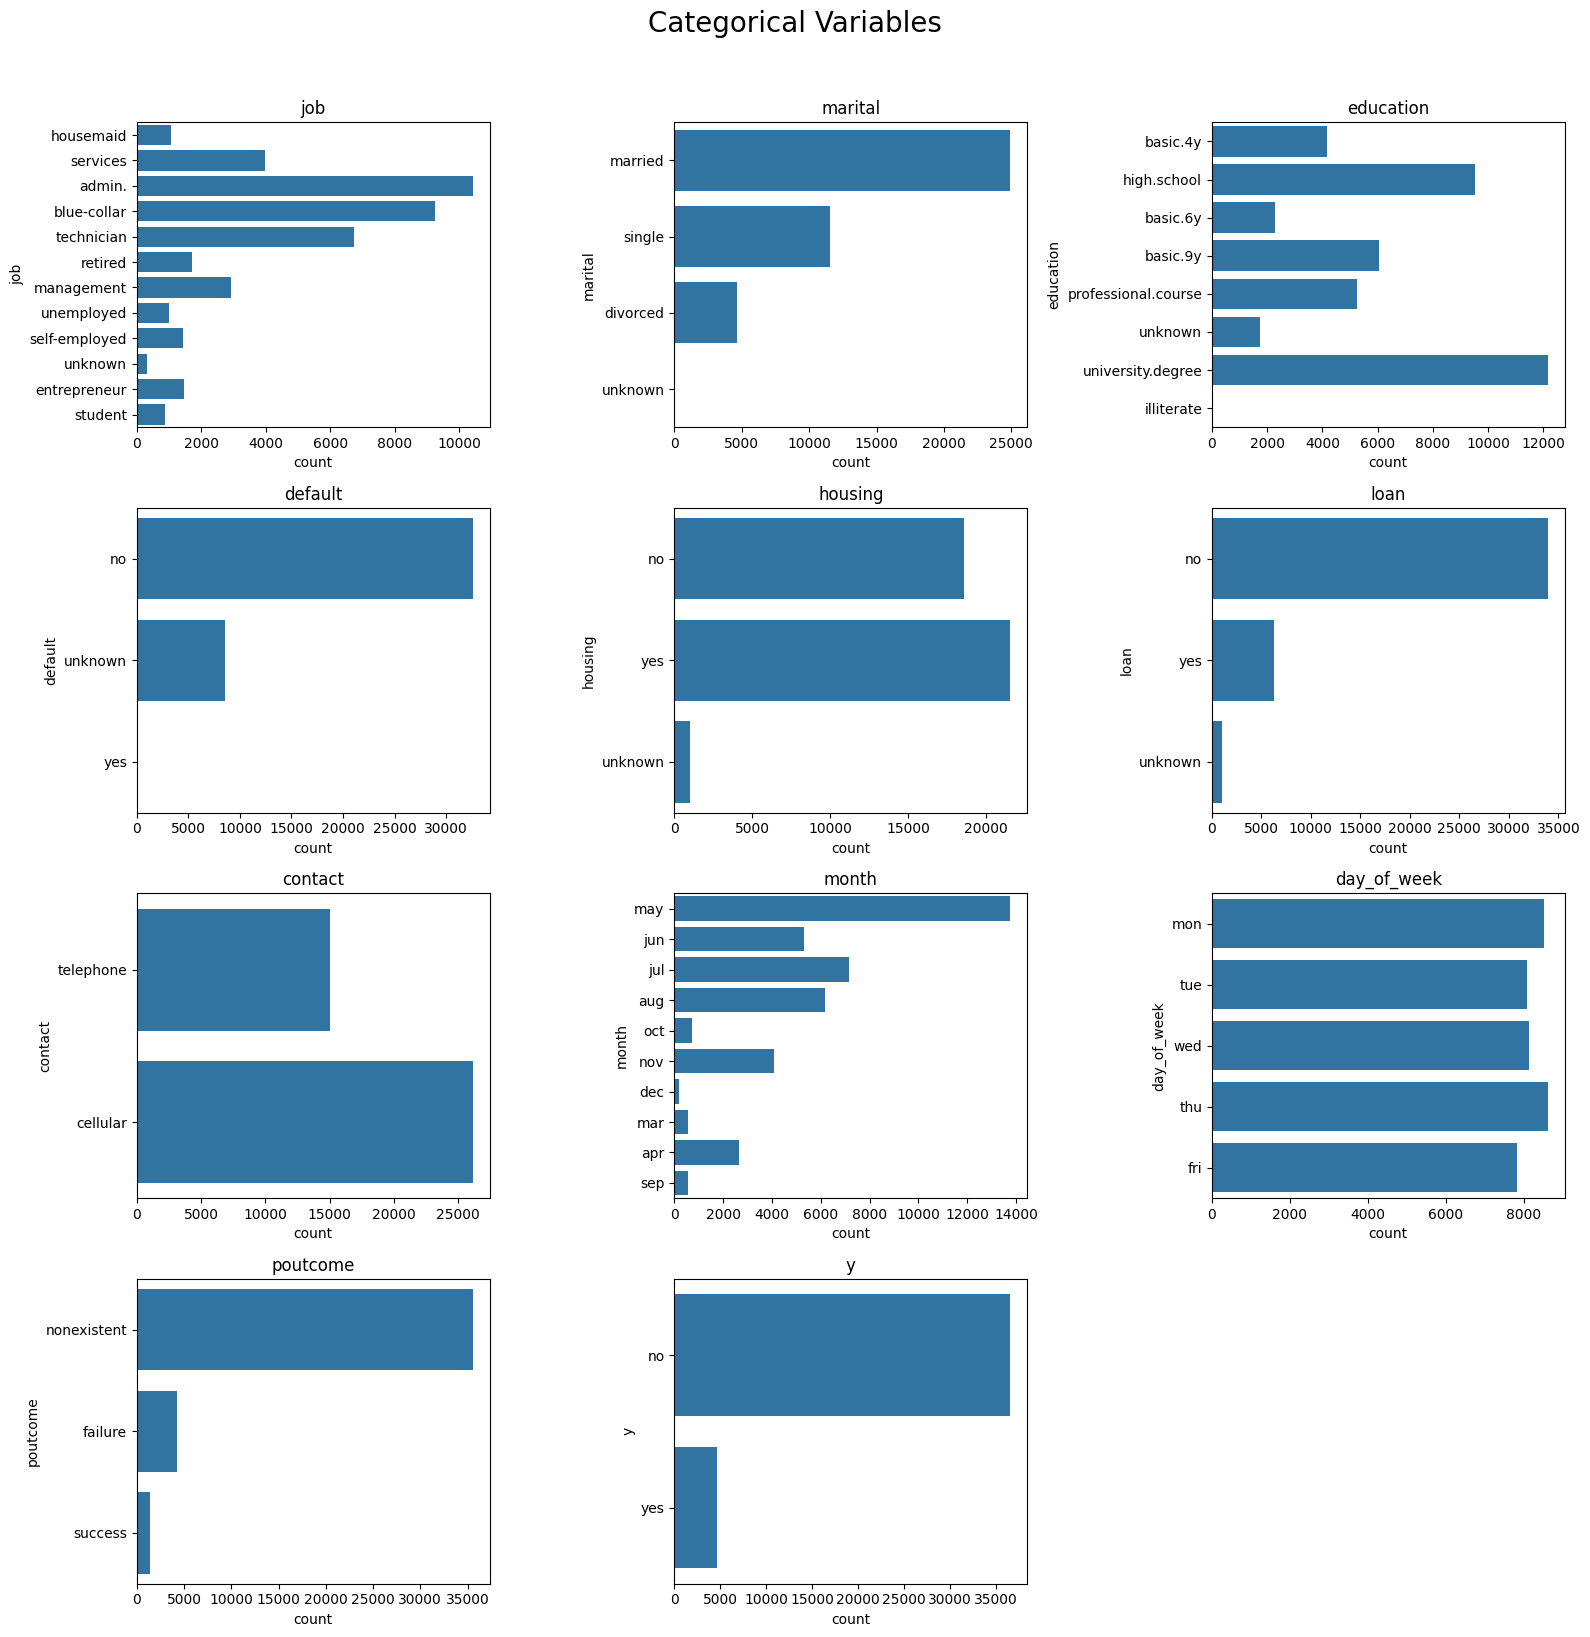

In [16]:
n = len(categorical_vars) # number of categorical variables

cols = 3
rows = math.ceil(n / cols) # automatically determine rows and columns

plt.figure(figsize=(16, rows * 4))

plt.suptitle("Categorical Variables", fontsize=20, y=1.02)

for i, col in enumerate(categorical_vars, start=1):
    plt.subplot(rows, cols, i)
    sns.countplot(data=bank_data_full, y=col)
    plt.title(col)

plt.tight_layout()
plt.show()

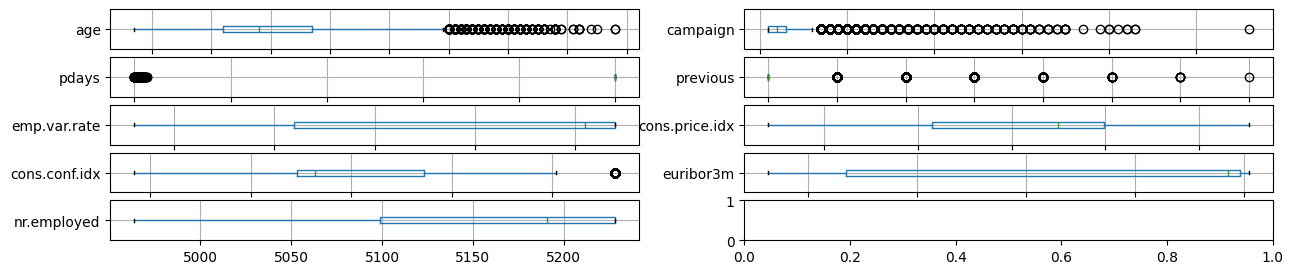

In [17]:
# number of boxes to plot is number of columns in df that are not an object.
columns_in_df = bank_data_full.select_dtypes(exclude='object').shape[1]

#number in columns in plot is 2 and number of rows is number of columns in df/number of columns in plot, rounded upwards
ncols = 2
nrows = math.ceil(columns_in_df/ncols)

fig, axs = plt.subplots(nrows, ncols, figsize=(15, 3) )

axsrow=0
axscol=0

for label, values in bank_data_full.items():
    if values.dtype != object:
        if axscol == 2:
            axsrow = axsrow + 1
            axscol = 0
        bank_data_full.boxplot(column=[label], vert=False, ax=axs[axsrow,axscol])
        axscol = axscol + 1

plt.xticks()
plt.show()    


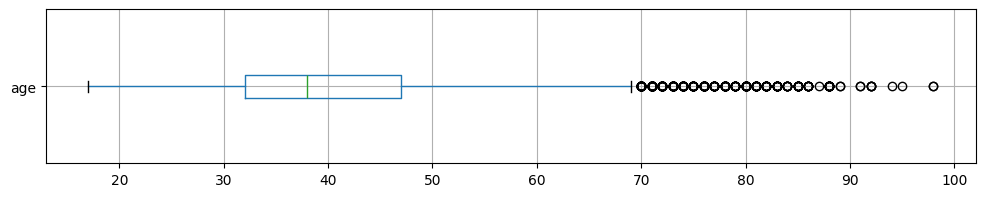

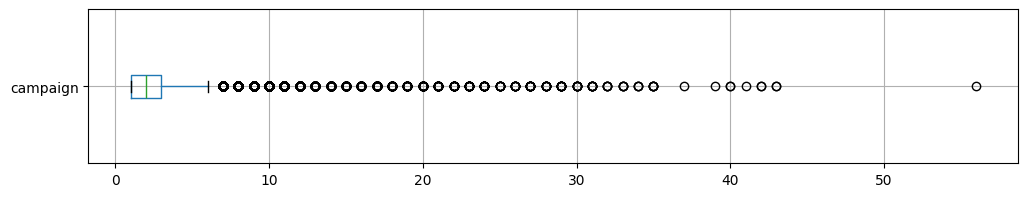

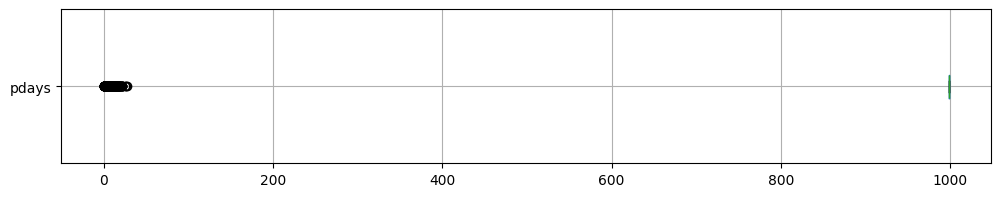

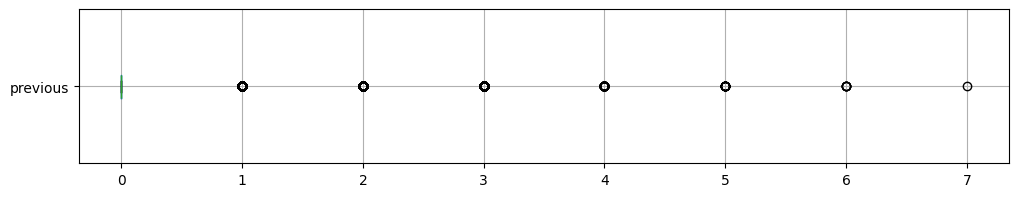

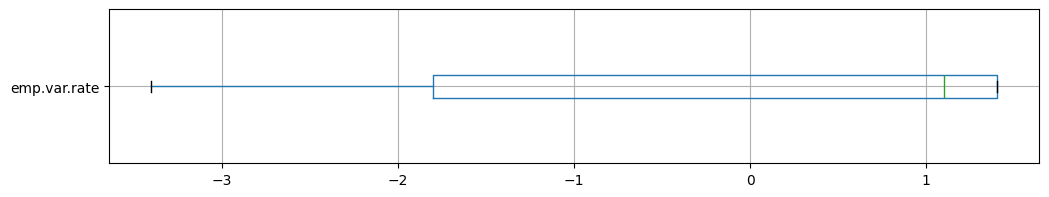

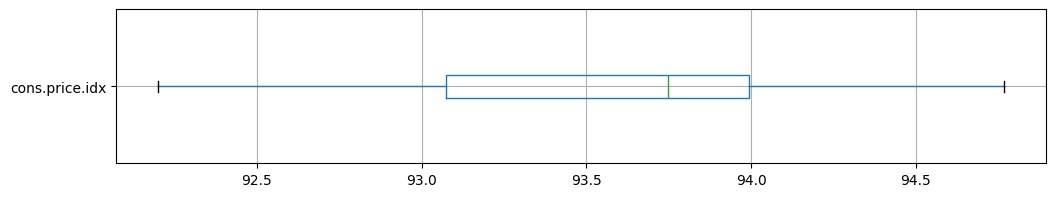

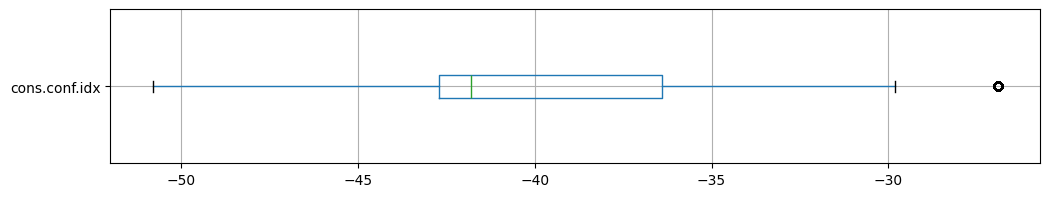

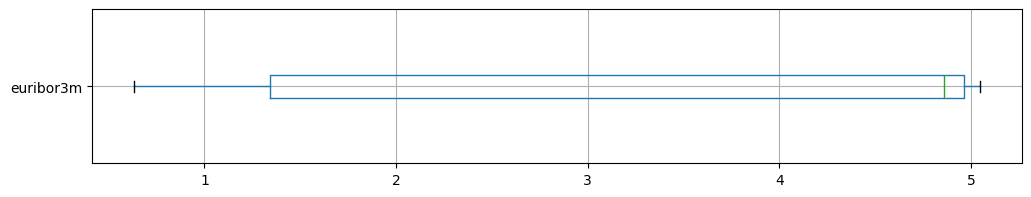

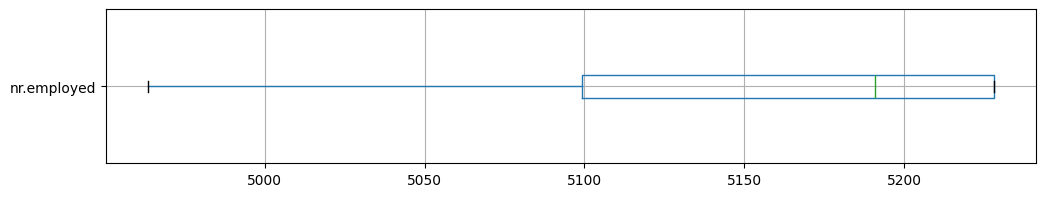

In [18]:
for label, values in bank_data_full.items():
    if values.dtype != object:
        bank_data_full.boxplot(column=[label], vert=False, figsize=(12, 2))
        plt.show()

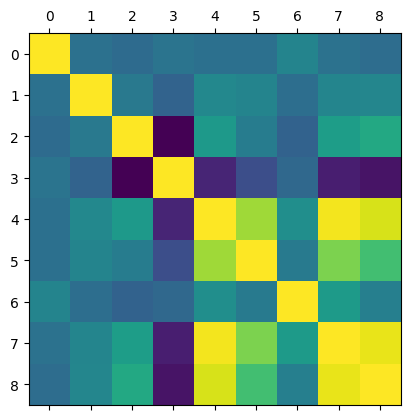

In [19]:
# Is there a correlation between features
# NOTE: this can only be done with numerical features
 
plt.matshow(bank_data_full.select_dtypes(exclude='object').corr())

<Axes: >

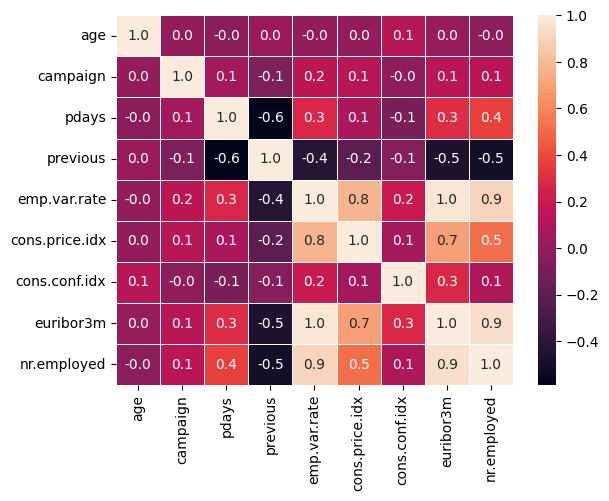

In [20]:
# What ss the correlation between features
# NOTE: this can only be done with numerical features
# NOTE 2: This means that this is not a way to determine a correlation with the target, because the target is yes/no

sns.heatmap(bank_data_full.select_dtypes(exclude='object').corr(), annot=True, linewidth=.5, fmt=".1f")

3 features hve a very high correlation (> 0.9): eurbor3m, emp.var.rate and nr.employed
Options are: 
- leave 2 out 
- combine the 3 to 1
- do nothing

### Make a binary from pdays

In [21]:

#Step 1: copy bank_data_fullto bank_data_full_p
bank_data_full_p = bank_data_full.copy()

#Step 2: add column based on Pdays
# Binary indicator
bank_data_full_p['contacted_before'] = (bank_data_full_p['pdays'] != 999).astype(int)

#step 3: remove column Pdays
bank_data_full_p = bank_data_full_p.drop(columns=['pdays'])

In [22]:
# split the dataframe i X and y
# in doing so, make yes=1 and no=0 (both as integer)
X = bank_data_full_p.drop("y", axis='columns')
y = bank_data_full_p["y"].replace(to_replace={'yes': '1', 'no': '0'}).astype(int)

In [23]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               41188 non-null  int64  
 1   job               41188 non-null  object 
 2   marital           41188 non-null  object 
 3   education         41188 non-null  object 
 4   default           41188 non-null  object 
 5   housing           41188 non-null  object 
 6   loan              41188 non-null  object 
 7   contact           41188 non-null  object 
 8   month             41188 non-null  object 
 9   day_of_week       41188 non-null  object 
 10  campaign          41188 non-null  int64  
 11  previous          41188 non-null  int64  
 12  poutcome          41188 non-null  object 
 13  emp.var.rate      41188 non-null  float64
 14  cons.price.idx    41188 non-null  float64
 15  cons.conf.idx     41188 non-null  float64
 16  euribor3m         41188 non-null  float6

In [24]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 41188 entries, 0 to 41187
Series name: y
Non-Null Count  Dtype
--------------  -----
41188 non-null  int64
dtypes: int64(1)
memory usage: 321.9 KB


## Split data into Train en Test

In [25]:
# Split te dataframe training and testset, using stratify, because yes/no is imbalanced

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape) #checking the shape of the splits
print("Train: ", len(X_train), "&",len(y_train))
print("Test: ", len(X_test), "&",len(y_test))

(32950, 19) (8238, 19) (32950,) (8238,)
Train:  32950 & 32950
Test:  8238 & 8238


# Create the generic pipeline

## Preprocessing

In [26]:
cat_pipeline = make_pipeline(OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
num_pipeline = make_pipeline(StandardScaler())

cat_features = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "day_of_week", "contacted_before"]
num_features = ["age", "campaign", "previous", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

preprocessing = ColumnTransformer([
    ("cat", cat_pipeline, cat_features),
    ("num", num_pipeline, num_features)
    ])

# Train and test several models

## Model Logistic Regression

### Logistic Regression pipeline

In [27]:
#LogisticRegression pipeline
log_reg = make_pipeline(preprocessing, LogisticRegression(random_state=42))

### Train basic LR model

In [28]:
# Training without crossvalidation
log_reg.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Evaluate LR model

#### Evaluate basic model on Train set

In [29]:
# Predict probability on TRAIN set
y_train_proba_lr = log_reg.predict_proba(X_train)

Logistic Regression Evaluation on Train set:
Precision: 0.660
Recall: 0.228
F1 Score: 0.339
AUC: 0.793


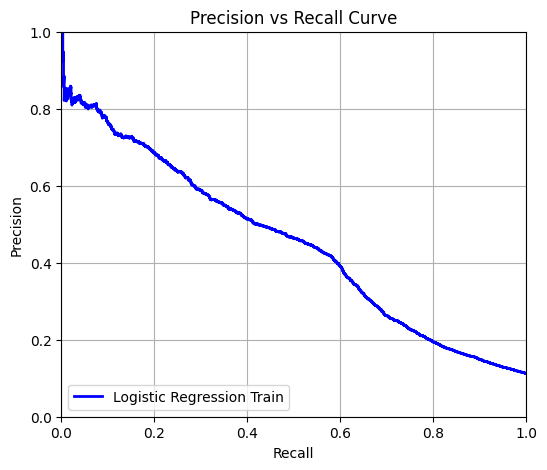

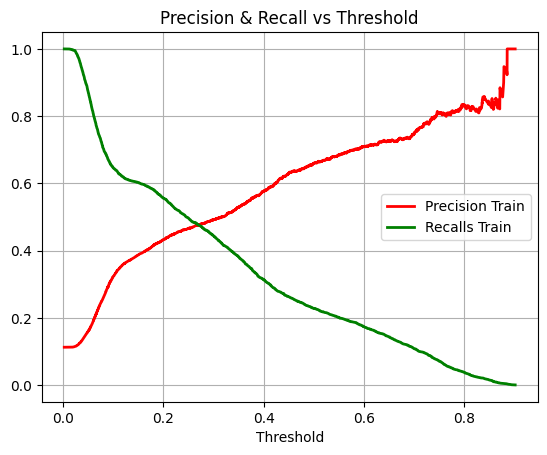

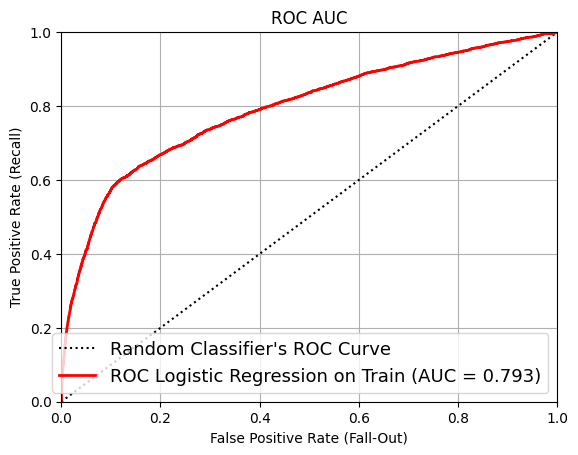

(0.660436137071651,
 0.22844827586206898,
 0.33947157726180943,
 0.7930244849935488)

In [30]:
#Evaluate the model on Train set
evaluateModel(y_train, y_train_proba_lr, "Logistic Regression", "Train")

#### Evaluate using Cross Validation on Train set

In [31]:
#LogisticRegression cross validated predict probalities on TRAINING set
y_train_proba_lr_cv = cross_val_predict(log_reg, X_train, y_train, cv=10, method="predict_proba")

Lineair Regression CV Evaluation on Train set:
Precision: 0.654
Recall: 0.227
F1 Score: 0.337
AUC: 0.789


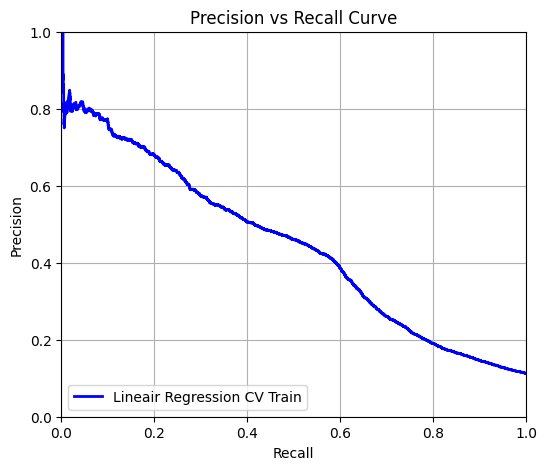

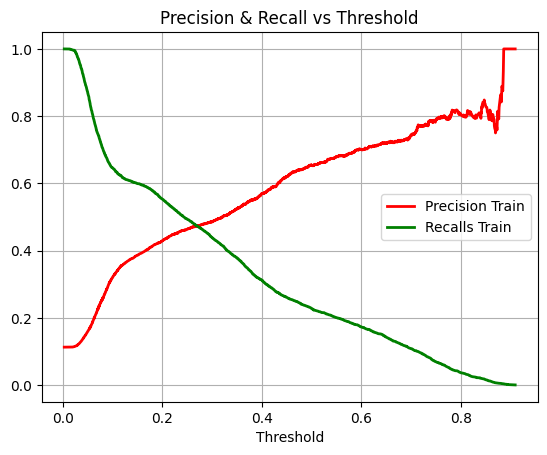

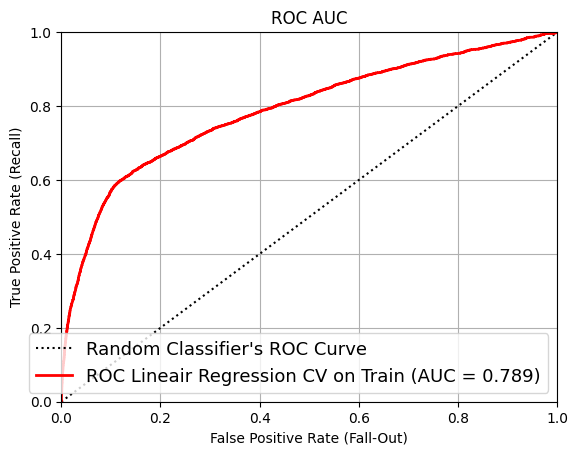

(0.6542635658914728,
 0.2273706896551724,
 0.33746501399440226,
 0.7890641354705498)

In [32]:
# Evaluate the model on Train set
evaluateModel(y_train, y_train_proba_lr_cv, "Lineair Regression CV", "Train")

#### Evaluate using Hyperparamater tuning & Cross Validation with GridSearch

The hyperparameters for Logistic regression are:
- Penalty
- Solver
- max_iter
- l1_ratio (Only used if penalty='elasticnet'. Setting l1_ratio=0 is equivalent to using penalty='l2', while setting l1_ratio=1 is equivalent to using penalty='l1'. For 0 < l1_ratio <1, the penalty is a combination of L1 and L2.)
- C (Inverse of regularization strength; must be a positive float. Smaller values specify stronger regularization.)

In [33]:
# Check the parameters of the baseline Logistic Regression model
log_reg.named_steps['logisticregression'].get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 42,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [34]:
param_grid = [    
    {'logisticregression__solver' : ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag'],
     'logisticregression__penalty' : ['l2', None],
     'logisticregression__max_iter' : [100, 500, 1000],
     'logisticregression__C': [0.1, 1, 10]
    },
    {'logisticregression__solver' : ['liblinear'],
     'logisticregression__penalty' : ['l1', 'l2'],
     'logisticregression__max_iter' : [100, 500, 1000],
     'logisticregression__C': [0.1, 1, 10]
    },
    {'logisticregression__solver' : ['saga'],
     'logisticregression__penalty' : ['l1', 'l2', None],
     'logisticregression__max_iter' : [100, 500, 1000],
     'logisticregression__C': [0.1, 1, 10]
    },
    {'logisticregression__solver' : ['saga'],
     'logisticregression__penalty' : ['elasticnet'],
     'logisticregression__max_iter' : [100, 500, 1000],
     'logisticregression__l1_ratio' : [0.1, 0.5, 0.9],
     'logisticregression__C': [0.1, 1, 10]
    }
    ]

#Using 10 folds in crossvalidating
log_reg_grid_search = GridSearchCV(log_reg, param_grid = param_grid, cv = 10, verbose=True, n_jobs=-1, error_score='raise')

log_reg_grid_search.fit(X_train, y_train)


Fitting 10 folds for each of 144 candidates, totalling 1440 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'logisticregression__C': [0.1, 1, ...], 'logisticregression__max_iter': [100, 500, ...], 'logisticregression__penalty': ['l2', None], 'logisticregression__solver': ['lbfgs', 'newton-cg', ...]}, {'logisticregression__C': [0.1, 1, ...], 'logisticregression__max_iter': [100, 500, ...], 'logisticregression__penalty': ['l1', 'l2'], 'logisticregression__solver': ['liblinear']}, ...]"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


In [35]:
log_reg_grid_search.best_params_

{'logisticregression__C': 0.1,
 'logisticregression__max_iter': 100,
 'logisticregression__penalty': 'l1',
 'logisticregression__solver': 'liblinear'}

In [36]:
# for future reference make the best estimator more easy to remember
lr_be = log_reg_grid_search.best_estimator_

#predict, using the best estimator
y_train_proba_lr_be = lr_be.predict_proba(X_train)

Lineair Regression BE Evaluation on Train set:
Precision: 0.674
Recall: 0.222
F1 Score: 0.334
AUC: 0.793


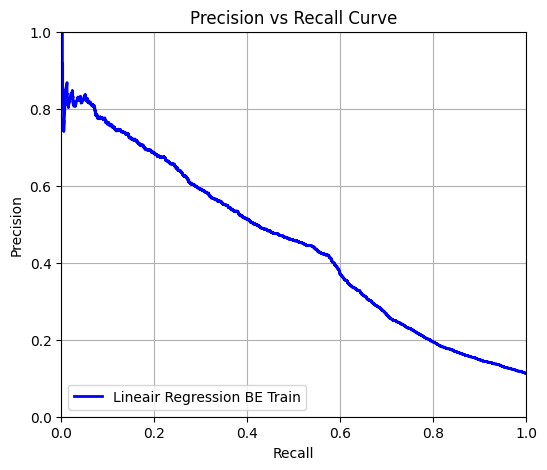

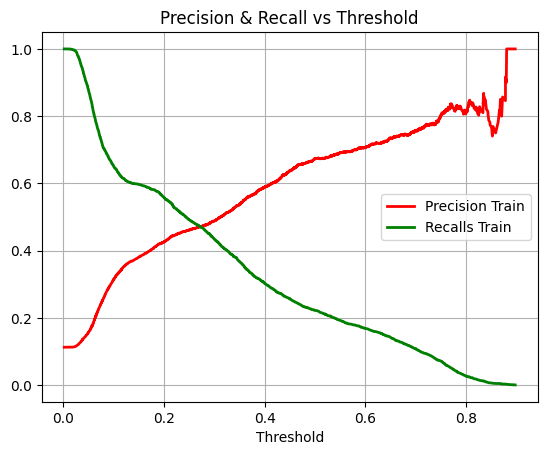

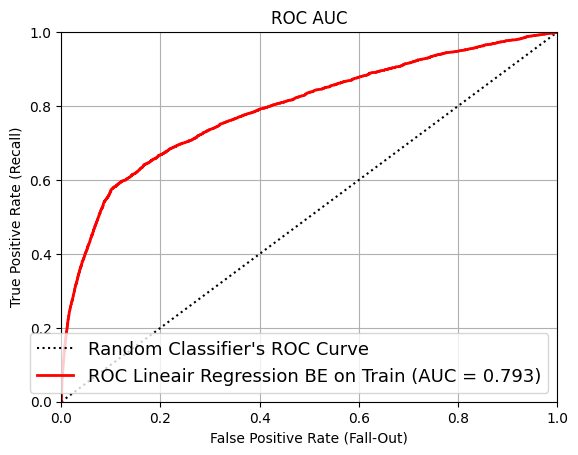

(0.6737530662305805,
 0.22198275862068967,
 0.33394123606889564,
 0.7925067917636708)

In [37]:
#Evaluate the model on Train set
evaluateModel(y_train, y_train_proba_lr_be, "Lineair Regression BE", "Train")

#### Evaluate Best Estimator on Test set

In [38]:
#predict probabilities, using the best estimator
y_test_proba_lr_be = lr_be.predict_proba(X_test)

#predict, using the best estimator
y_test_pred_lr_be = lr_be.predict(X_test)

Lineair Regression BE Evaluation on Test set:
Precision: 0.697
Recall: 0.216
F1 Score: 0.329
AUC: 0.800


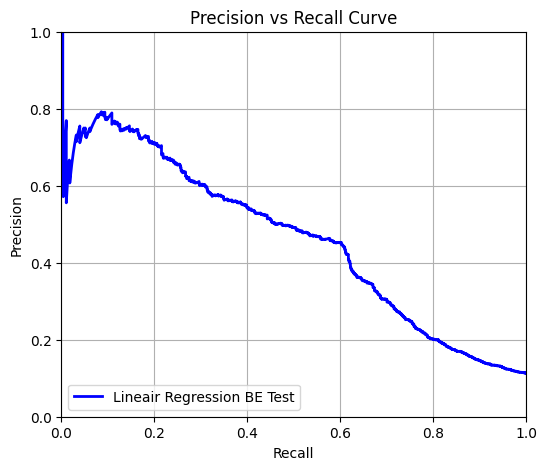

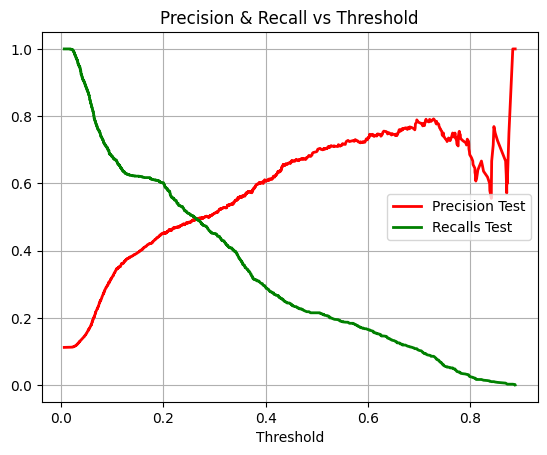

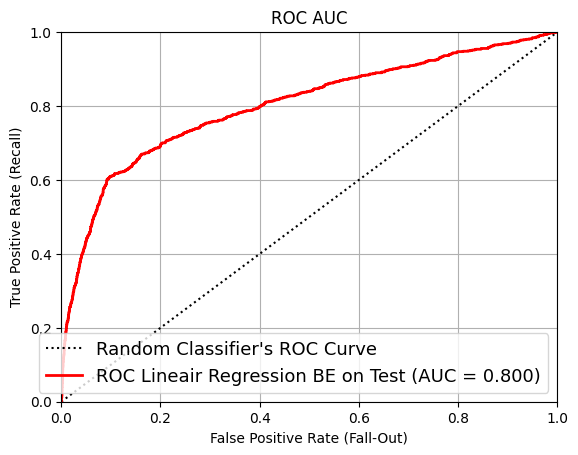

In [39]:
#Evaluate the model on Test set
lr_be_precision, lr_be_recall, lr_be_f1, lr_be_auc_score = evaluateModel(y_test, y_test_proba_lr_be, "Lineair Regression BE", "Test")

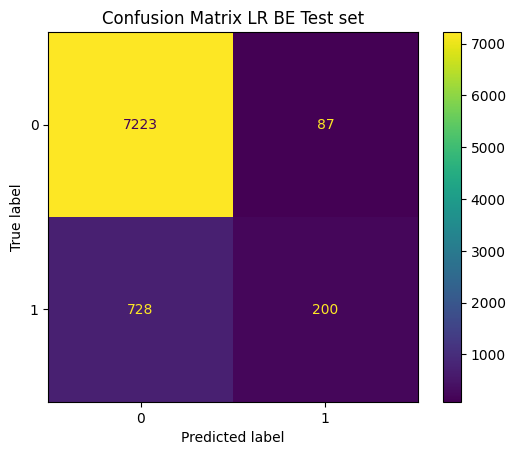

In [40]:

#Confusion Matrix Test set with best estimator
conf_matrix_be_lr = confusion_matrix(y_test, y_test_pred_lr_be)  
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_be_lr,
                              display_labels=lr_be.classes_)
disp.plot()
plt.title("Confusion Matrix LR BE Test set")
plt.show()

#### Conclusion of evaluation
- Using TRAIN set:
    - Curves & scores on basic model show that the model does not underfit
    - Curves & scores on cross validated model show that the model does not underfit
    - Curves & scores on best estimator (hyperparameter tuned) show that the model does not underfit
- Using TEST set 
    - Curves & scores on best estimator shouw that the model does not overfit
    
**--> Best LR model is usable**

### Costbased Thresholding LR

#### Calculation of Costs & Optimal threshold

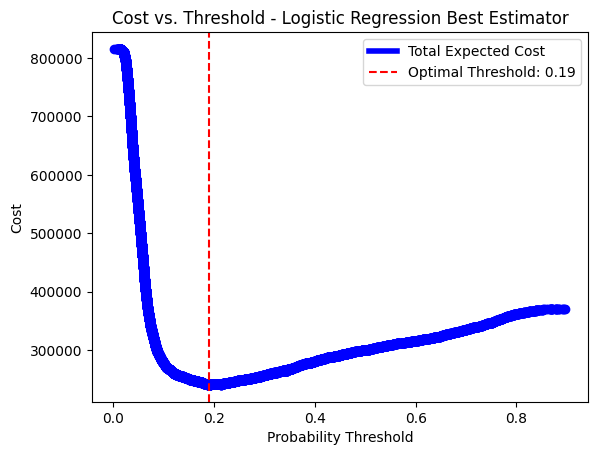

Optimal threshold for Logistic Regression Best Estimator: 0.19
Precision: 0.42
Recall: 0.57
Empirically minimized expected costs: 240170.20
Empirically minimized expected costs per item: 7.29
 
With calibrated p threshold would be: 0.22
Expected cost with this calibrated p threshold: 242196.70


In [41]:
# use the TRAIN set to determine the optimal threshold
th_lr = empirical_costbased_thresholding(y_train, y_train_proba_lr_be[:,1], "Logistic Regression Best Estimator", cost_unsuccesfull_call, cost_missed_call, p=True)

#### Average Cost

In [42]:
# use the TEST set and the TRAINED Threshold to determine average call cost.
y_pred_lr = (lr_be.predict_proba(X_test)[:,1]) > th_lr
av_testscore_lr = myAveragedCosts(y_test, y_pred_lr, cost_unsuccesfull_call, cost_missed_call)
print(f'Logreg Av Costs: €{av_testscore_lr:.2f}')

Logreg Av Costs: €6.83


## Model Random Forest

### Random Forest Pipeline

In [43]:
#random forest pipeline
rf_clf = make_pipeline(preprocessing, RandomForestClassifier(random_state=42))  


### Train basic RF model

In [44]:
# Training the Random Forest Classifier
rf_clf.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Evaluate RF Model

#### Evaluate basic model on Train set


In [45]:
# Predict probabilities on TRAIN set
y_train_proba_rf = rf_clf.predict_proba(X_train)


Random Forest Evaluation on Train set:
Precision: 0.994
Recall: 0.964
F1 Score: 0.979
AUC: 1.000


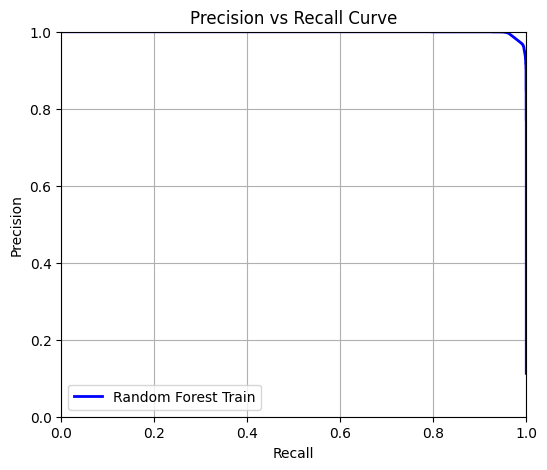

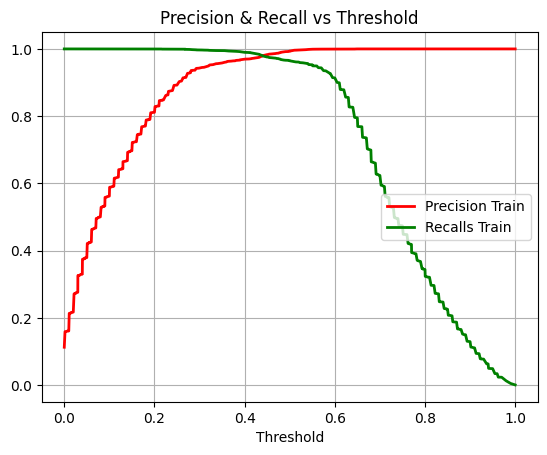

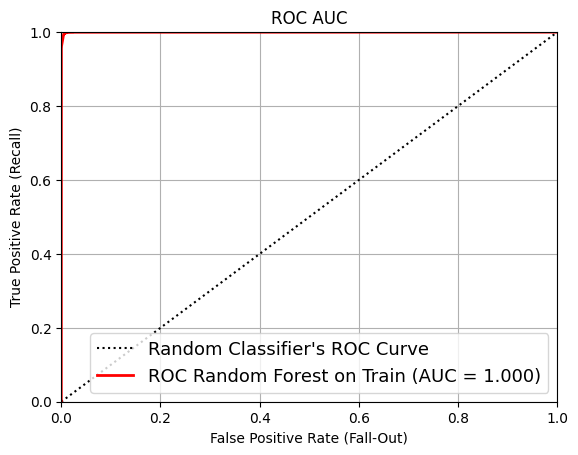

(0.993616430752151, 0.9644396551724138, 0.9788106630211894, 0.9998533420578086)

In [46]:
##Evaluate the model on Train set
evaluateModel(y_train, y_train_proba_rf, "Random Forest", "Train")


#### Evaluate using Cross Validation on Train set


In [47]:
#Random Forest cross validated predict probalities on TRAINING set
y_train_proba_rf_cv = cross_val_predict(rf_clf, X_train, y_train, cv=10, method="predict_proba")

Random Forest CV Evaluation on Train set:
Precision: 0.533
Recall: 0.280
F1 Score: 0.368
AUC: 0.770


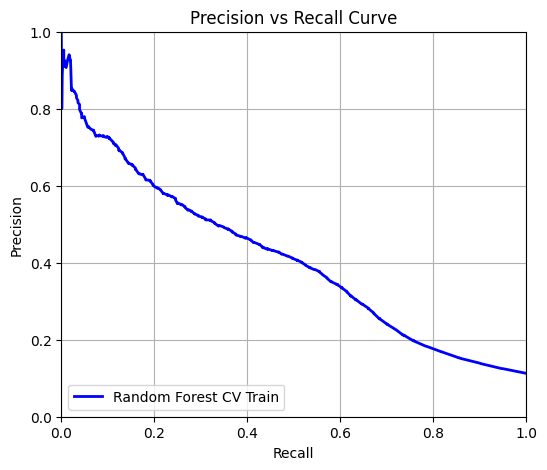

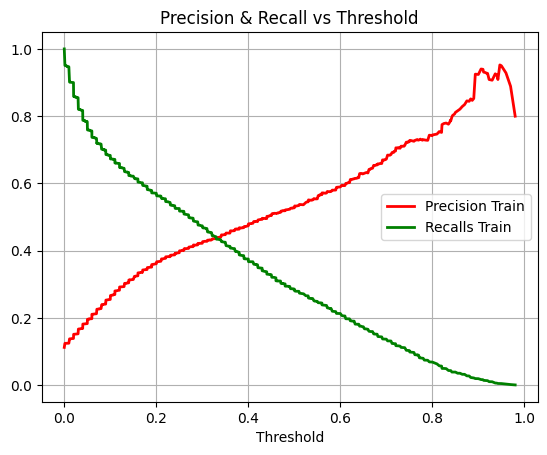

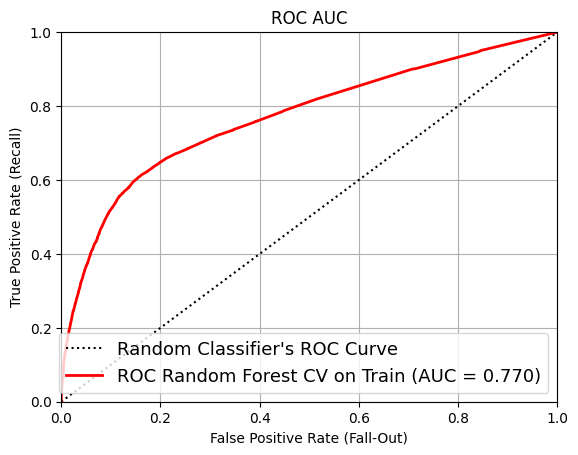

(0.5332991803278688,
 0.28044181034482757,
 0.3675847457627119,
 0.7700859601478119)

In [48]:
#Evaluate the model on TRAIN set
evaluateModel(y_train, y_train_proba_rf_cv, "Random Forest CV", "Train")


#### Evaluate using Hyperparameter tuning & Cross Validation with Gridsearch

Useful Hyperparameters are:
- model__n_estimators (Number of trees in the forest: Trying 100 or 300 trees)
- model__max_depth (Maximum depth of each tree)
- model__min_samples_split (Minimum number of samples required to split a node)

In [49]:
param_grid_rf = {
    "randomforestclassifier__n_estimators": [350, 400],
    "randomforestclassifier__max_depth": [None, 10, 20],
    "randomforestclassifier__min_samples_split": [10, 15, 20]
}

rf_grid_search = GridSearchCV(rf_clf, param_grid = param_grid_rf, cv = 10, verbose=True, n_jobs=-1, error_score='raise')

rf_grid_search.fit(X_train, y_train)

Fitting 10 folds for each of 18 candidates, totalling 180 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'randomforestclassifier__max_depth': [None, 10, ...], 'randomforestclassifier__min_samples_split': [10, 15, ...], 'randomforestclassifier__n_estimators': [350, 400]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


In [50]:
rf_grid_search.best_params_

{'randomforestclassifier__max_depth': 10,
 'randomforestclassifier__min_samples_split': 10,
 'randomforestclassifier__n_estimators': 350}

In [51]:
# for future reference make the best estimator more easy to remember
rf_be = rf_grid_search.best_estimator_

#predict, using the best estimator
y_train_proba_rf_be = rf_be.predict_proba(X_train)

Random Forest BE Evaluation on Train set:
Precision: 0.795
Recall: 0.268
F1 Score: 0.401
AUC: 0.842


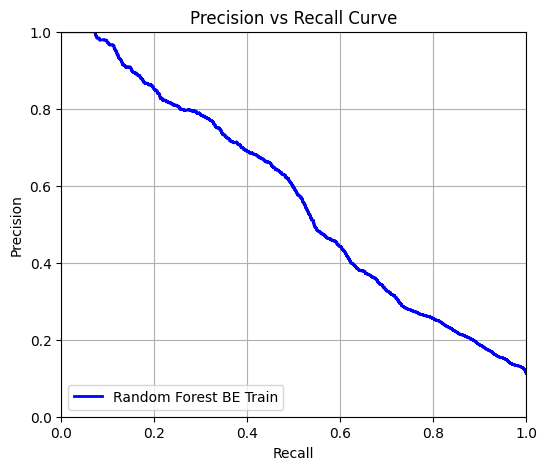

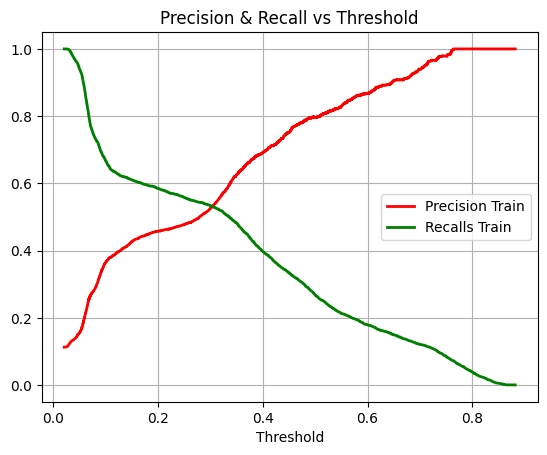

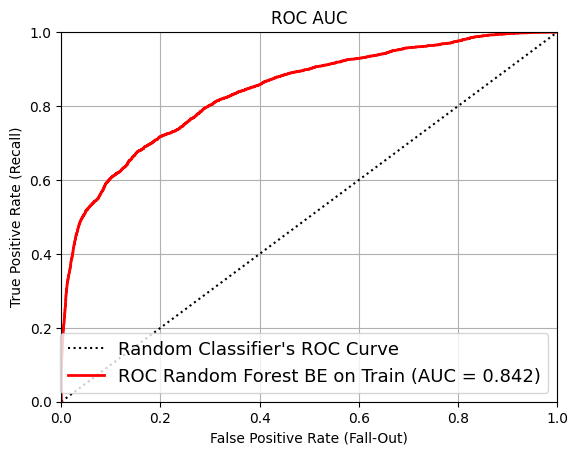

(0.7952, 0.2677801724137931, 0.40064490124949614, 0.8418981774279338)

In [52]:
#Evaluate the model on TRAIN set
evaluateModel(y_train, y_train_proba_rf_be, "Random Forest BE", "Train")


#### Evaluate Best Estimator on Test set


In [53]:
#predict probabilities, using the best estimator
y_test_proba_rf_be = rf_be.predict_proba(X_test)

#predict, using the best estimator
y_test_pred_rf_be = rf_be.predict(X_test)

Random Forest BE Evaluation on Test set:
Precision: 0.704
Recall: 0.223
F1 Score: 0.339
AUC: 0.811


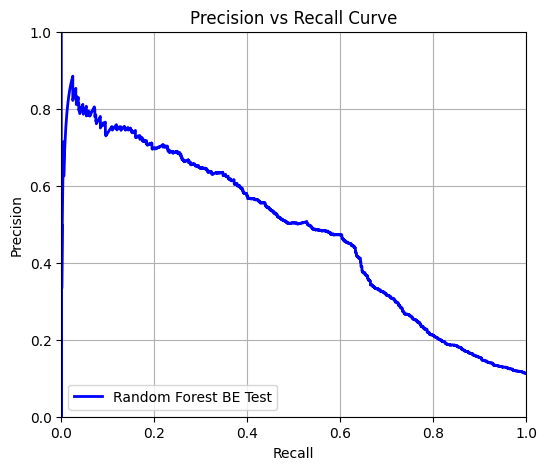

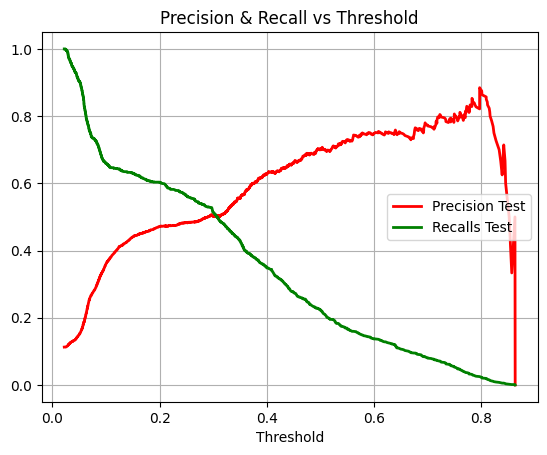

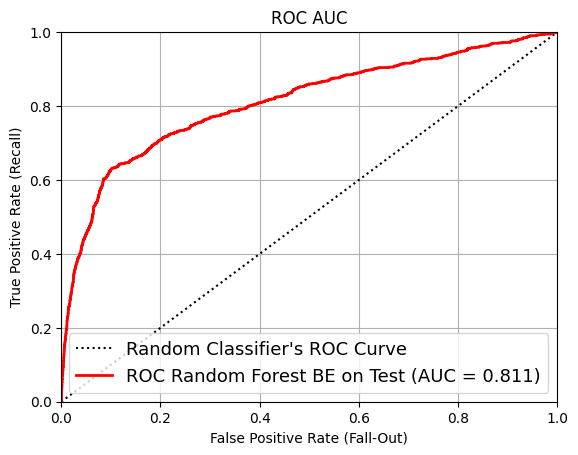

In [54]:
#Evaluate the model on Test set
rf_be_precision, rf_be_recall, rf_be_f1, rf_be_auc_score = evaluateModel(y_test, y_test_proba_rf_be, "Random Forest BE", "Test")

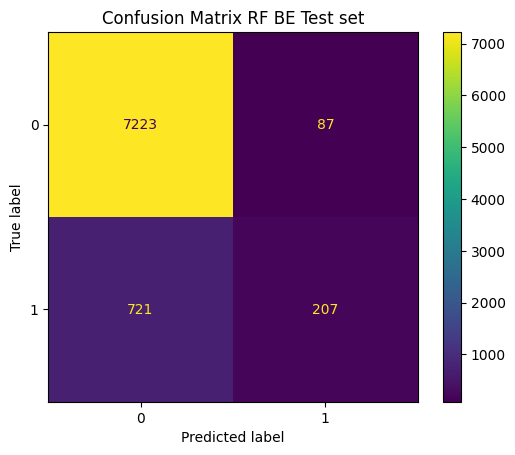

In [55]:
#Confusion Matrix Test set with best estimator
conf_matrix_be_rf = confusion_matrix(y_test, y_test_pred_rf_be)  
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_be_rf,
                              display_labels=rf_be.classes_)
disp.plot()
plt.title("Confusion Matrix RF BE Test set")
plt.show()

#### Conclusion of evaluation
- Using TRAIN set:
    - Curves & scores on basic model show that the model does overfit (AUC = 1)
    - Curves & scores on cross validated model show that the model does not overfit or underfit
    - Curves & scores on best estimator (hyperparameter tuned) show that the model does not overfit or underfit
- Using TEST set 
    - Curves & scores on best estimator shouw that the model does not overfit
    
**--> Best RF model is usable**


### Costbased Thresholding RF

#### Calculation of Costs & Optimal threshold

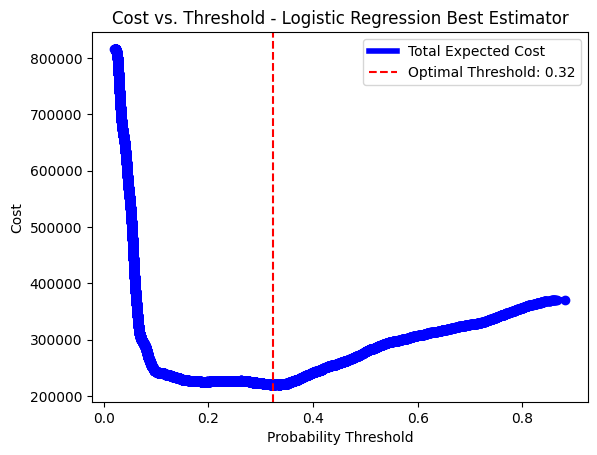

Optimal threshold for Logistic Regression Best Estimator: 0.32
Precision: 0.57
Recall: 0.52
Empirically minimized expected costs: 219961.90
Empirically minimized expected costs per item: 6.68
 
With calibrated p threshold would be: 0.22
Expected cost with this calibrated p threshold: 226985.10


In [56]:
# use the TRAIN set to determine the optimal threshold
th_rf = empirical_costbased_thresholding(y_train, y_train_proba_rf_be[:,1], "Logistic Regression Best Estimator", cost_unsuccesfull_call, cost_missed_call, p=True)

#### Average Cost

In [57]:
# use the TEST set and the TRAINED Threshold to determine average call cost.
y_pred_rf = (rf_be.predict_proba(X_test)[:,1]) > th_rf
av_testscore_rf = myAveragedCosts(y_test, y_pred_rf, cost_unsuccesfull_call, cost_missed_call)
print(f'Logreg Av Costs: €{av_testscore_rf:.2f}')

Logreg Av Costs: €7.35


## Model KNN (5)

### KNN Pipeline

In [58]:
#KNeighbors pipeline
knn_clf = make_pipeline(preprocessing, KNeighborsClassifier())  

### Train basic KNN model

In [59]:
#Training the KNeighbors Classifier
knn_clf.fit(X_train, y_train)   

,steps,"[('columntransformer', ...), ('kneighborsclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Evaluate KNN

#### Evaluate basic model on Train set

In [60]:
# Predict probabilities on TRAIN set
y_train_proba_knn = knn_clf.predict_proba(X_train)

KNN Evaluation on Train set:
Precision: 0.712
Recall: 0.374
F1 Score: 0.491
AUC: 0.925


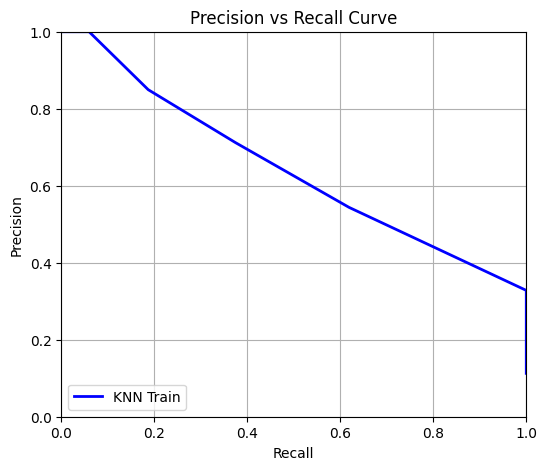

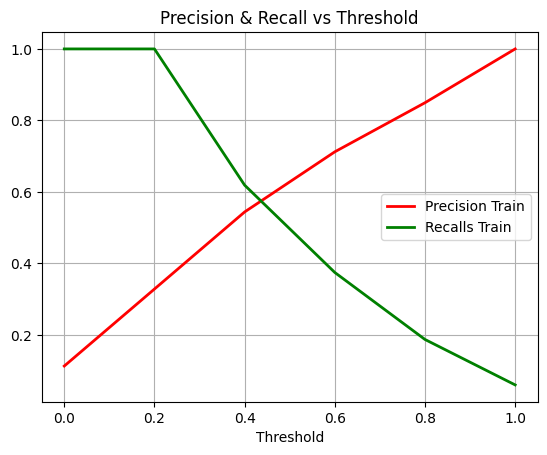

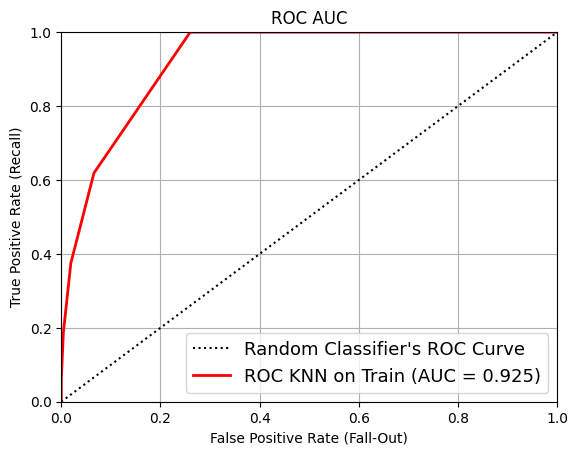

(0.7120901639344263, 0.3744612068965517, 0.490819209039548, 0.9250242298417152)

In [61]:
#Evaluate the model TRAIN set
evaluateModel(y_train, y_train_proba_knn, "KNN", "Train")

#### Evaluate using Cross Validation on Train set

In [62]:
#cross validated predict probalities on TRAINING set
y_train_proba_knn_cv = cross_val_predict(knn_clf, X_train, y_train, cv=5, method="predict_proba") 

KNN CV Evaluation on Train set:
Precision: 0.508
Recall: 0.267
F1 Score: 0.350
AUC: 0.719


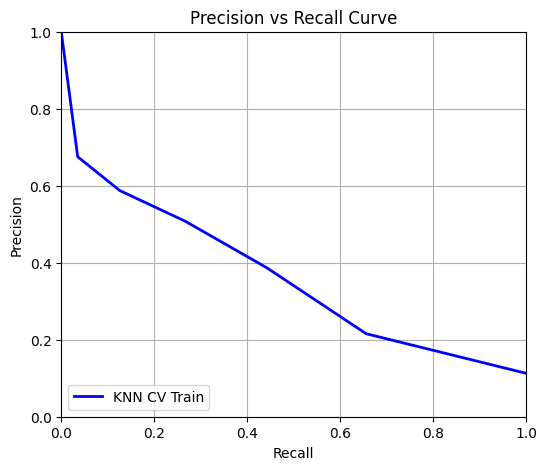

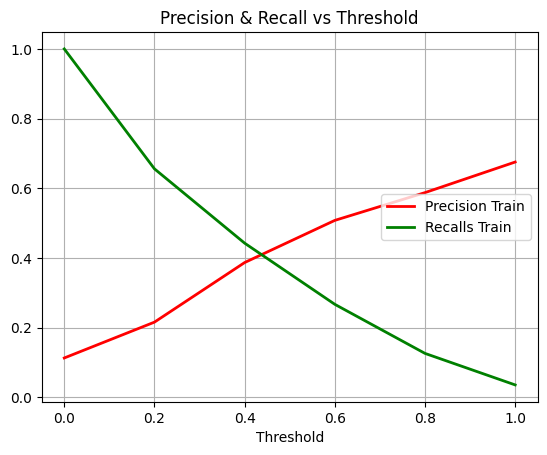

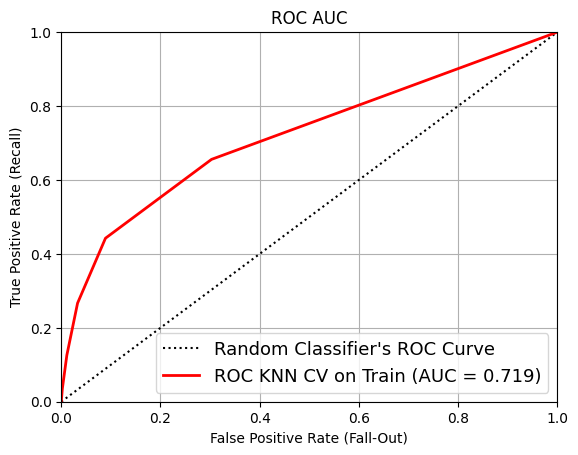

(0.5076923076923077,
 0.2667025862068966,
 0.34969975273754855,
 0.7194318161547562)

In [63]:
#Evaluate the model on TRAIN set
evaluateModel(y_train, y_train_proba_knn_cv, "KNN CV", "Train")

#### Evaluate using Hyperparameter tuning & Cross Validation with Gridsearch

Parameters:
- model__n_neighbors (The number of nearest neighbors KNN uses to make a prediction)
- model__weights (How each neighbor contributes to the prediction. Options: "uniform" → every neighbor has equal weight. "distance" → closer neighbors count more than farther ones).

In [64]:
param_grid_knn = {
    "kneighborsclassifier__n_neighbors": [5, 20, 100],
    "kneighborsclassifier__weights": ["uniform", "distance"]
}

knn_grid_search = GridSearchCV(knn_clf, param_grid = param_grid_knn, cv = 10, verbose=True, n_jobs=-1, error_score='raise')

knn_grid_search.fit(X_train, y_train)

Fitting 10 folds for each of 6 candidates, totalling 60 fits


,estimator,Pipeline(step...lassifier())])
,param_grid,"{'kneighborsclassifier__n_neighbors': [5, 20, ...], 'kneighborsclassifier__weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


In [65]:
knn_grid_search.best_params_

{'kneighborsclassifier__n_neighbors': 20,
 'kneighborsclassifier__weights': 'uniform'}

In [66]:
# for future reference make the best estimator more easy to remember
knn_be = knn_grid_search.best_estimator_

#predict, using the best estimator
y_train_proba_knn_be = knn_be.predict_proba(X_train)

KNN BE Evaluation on Train set:
Precision: 0.694
Recall: 0.238
F1 Score: 0.355
AUC: 0.858


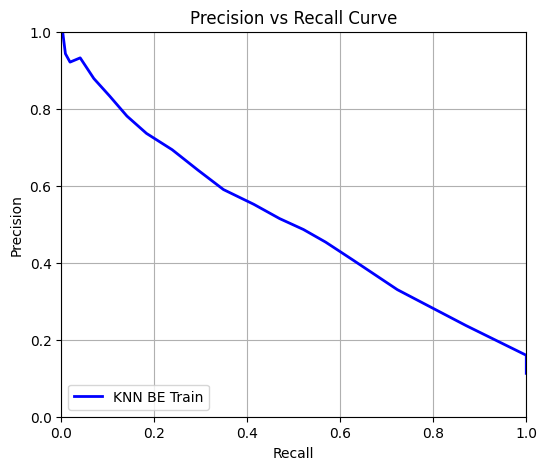

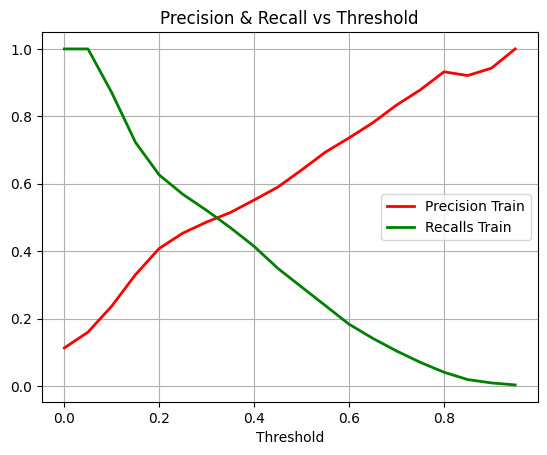

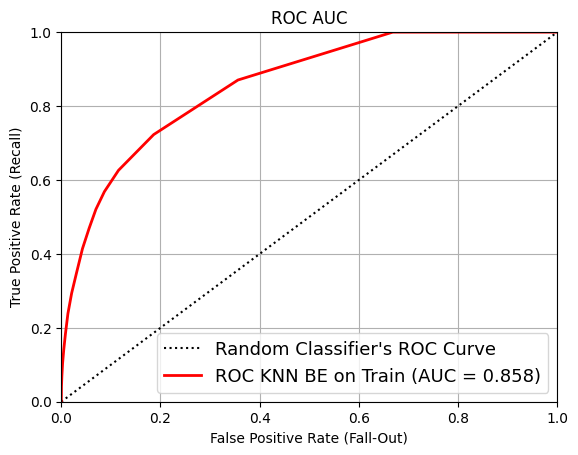

(0.6935736677115988,
 0.23841594827586207,
 0.35485164394546914,
 0.8575548318452486)

In [67]:
#Evaluate the model on TRAIN set
evaluateModel(y_train, y_train_proba_knn_be, "KNN BE", "Train")

#### Evaluate Beste Estimator on Test set

In [68]:
#predict probabilities, using the best estimator
y_test_proba_knn_be = knn_be.predict_proba(X_test)

#predict, using the best estimator
y_test_pred_knn_be = knn_be.predict(X_test)

KNN BE Evaluation on Test set:
Precision: 0.651
Recall: 0.216
F1 Score: 0.324
AUC: 0.777


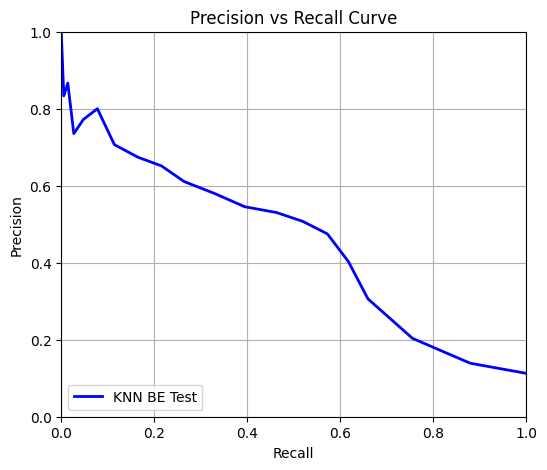

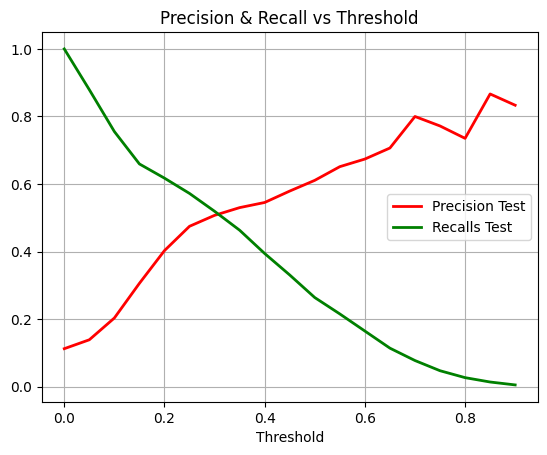

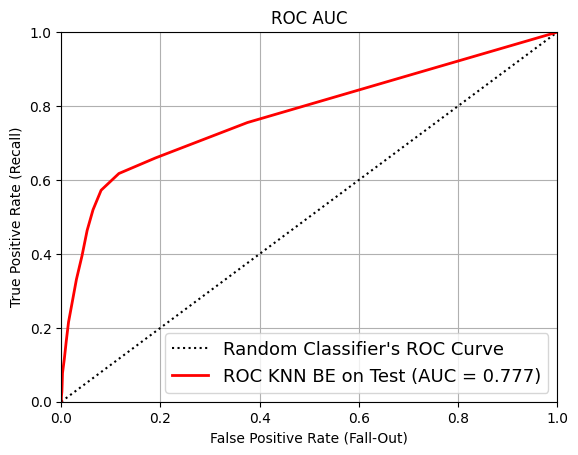

In [69]:
# #Evaluate the model on TEST set
knn_be_precision, knn_be_recall, knn_be_f1, knn_be_auc_score = evaluateModel(y_test, y_test_proba_knn_be, "KNN BE", "Test")

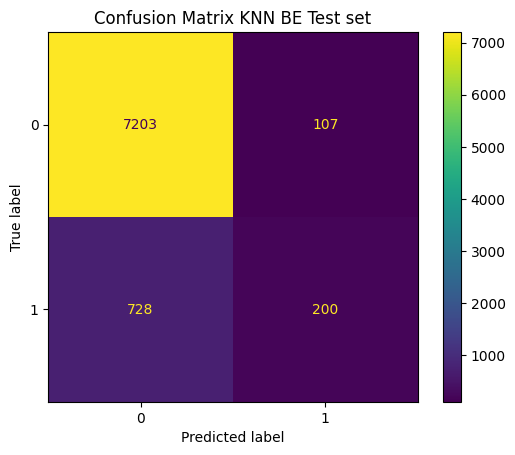

In [70]:
#Confusion Matrix Test set with best estimator
conf_matrix_be_knn = confusion_matrix(y_test, y_test_pred_knn_be)  
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_be_knn,
                              display_labels=knn_be.classes_)
disp.plot()
plt.title("Confusion Matrix KNN BE Test set")
plt.show()

#### Conclusion of evaluation
- Using TRAIN set:
    - Curves & scores on basic model show that the model is suspect to overfit (AUC > 0.9)
    - Curves & scores on cross validated model show that the model does not underfit or overfit
    - Curves & scores on best estimator (hyperparameter tuned) show that the model does not underfit or overfit
- Using TEST set 
    - Curves & scores on best estimator shouw that the model does overfit
    
**--> Best KNN model is not usable**

### Costbased Thresholding KNN

#### Calculation of cost & Optimal threshold

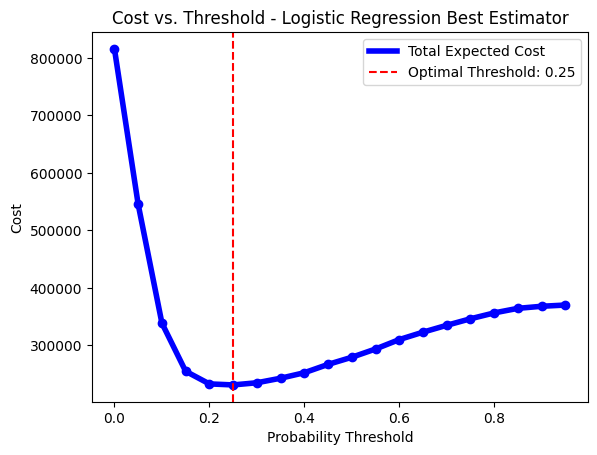

Optimal threshold for Logistic Regression Best Estimator: 0.25
Precision: 0.45
Recall: 0.57
Empirically minimized expected costs: 231121.80
Empirically minimized expected costs per item: 7.01
 
With calibrated p threshold would be: 0.22
Expected cost with this calibrated p threshold: 231121.80


In [71]:
# use the TRAIN set to determine the optimal threshold
th_knn = empirical_costbased_thresholding(y_train, y_train_proba_knn_be[:,1], "Logistic Regression Best Estimator", cost_unsuccesfull_call, cost_missed_call, p=True)

#### Average Cost

In [72]:
# use the TEST set and the TRAINED Threshold to determine average call cost.
y_pred_knn = (knn_be.predict_proba(X_test)[:,1]) > th_knn
av_testscore_knn = myAveragedCosts(y_test, y_pred_knn, cost_unsuccesfull_call, cost_missed_call)
print(f'Logreg Av Costs: €{av_testscore_knn:.2f}')

Logreg Av Costs: €7.00


## Gradient Boosting

### Gradient Boosting Pipeline

In [73]:
# Gradient Boosting pipeline
gb_clf = make_pipeline(preprocessing, GradientBoostingClassifier(random_state=42))


### Train basic Gradient Boosting model

In [74]:

# Training the Gradient Boosting Classifier
gb_clf.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Evaluatue Gradient Boosting

#### Evaluatue basic model on Train set

In [75]:
# Predict probability on TRAIN set
y_train_proba_gb = gb_clf.predict_proba(X_train)

Gradient Boosting Evaluation on Train set:
Precision: 0.715
Recall: 0.262
F1 Score: 0.383
AUC: 0.805


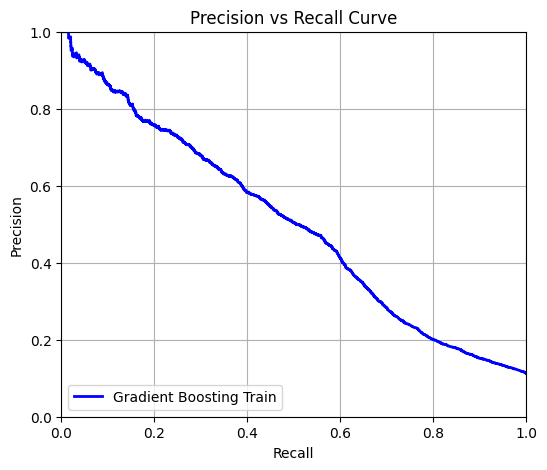

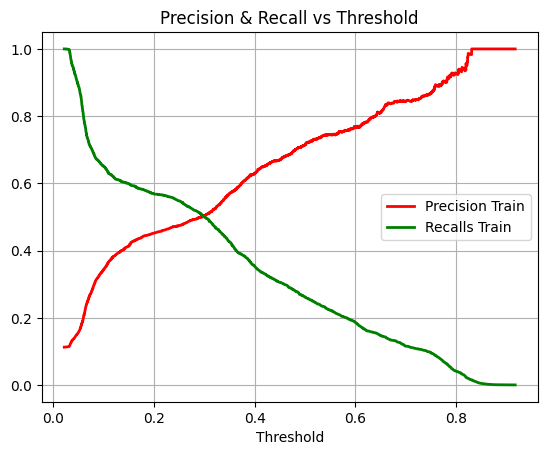

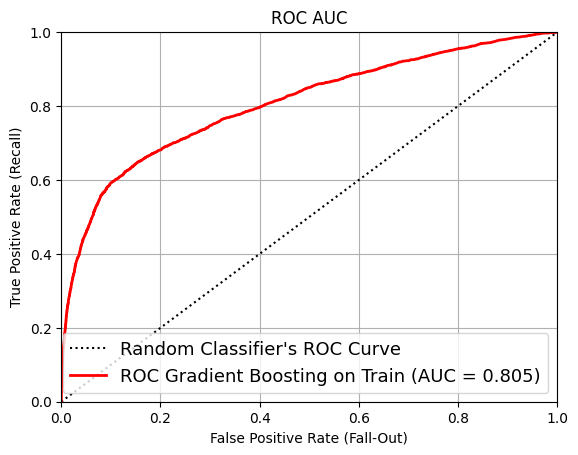

(0.7147058823529412,
 0.26185344827586204,
 0.3832807570977918,
 0.8054383606537076)

In [76]:
#Evaluate the model on Train set
evaluateModel(y_train, y_train_proba_gb, "Gradient Boosting", "Train")

#### Evaluate using Cross Validation on Train set

In [77]:
# Cross-validated predicted probabilities on TRAINING set
y_train_proba_gb_cv = cross_val_predict(gb_clf, X_train, y_train, cv=10, method="predict_proba")

Gradient Boosting CV Evaluation on Train set:
Precision: 0.650
Recall: 0.240
F1 Score: 0.350
AUC: 0.795


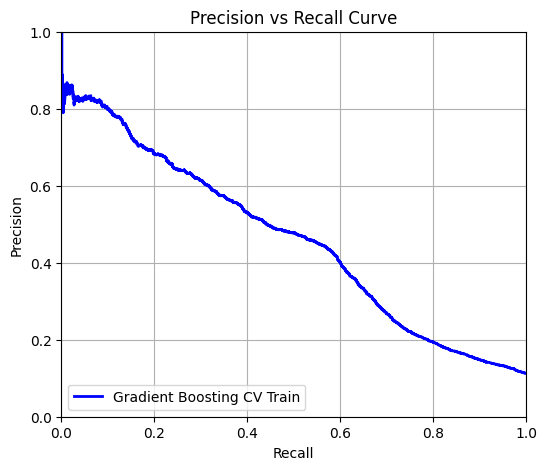

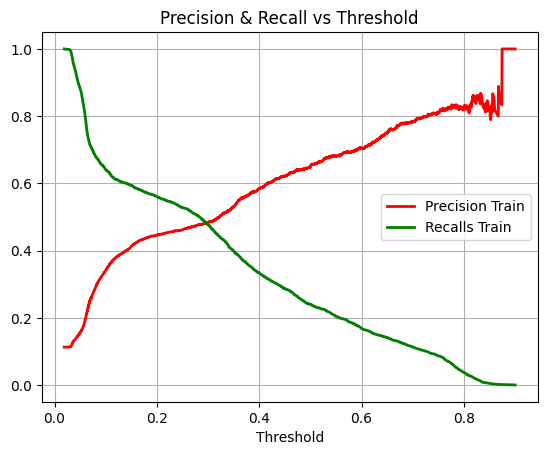

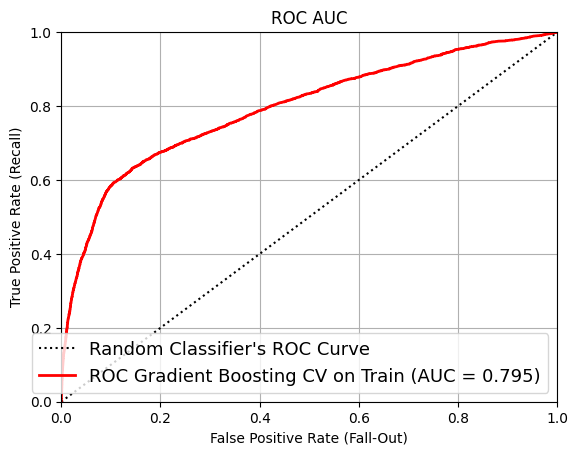

(0.6501095690284879,
 0.23976293103448276,
 0.3503247392245621,
 0.7947178465937101)

In [78]:
# Evaluate the model on Train set
evaluateModel(y_train, y_train_proba_gb_cv, "Gradient Boosting CV", "Train")

#### Evaluate using Hyperparamater tuning & Cross Validation with GridSearch

Most important:

- n_estimators
Number of boosting stages (trees)
Controls model capacity
Typical values:
n_estimators = [50, 100, 200, 300]

- learning_rate
Shrinks the contribution of each tree
Lower values → better generalization, need more trees
learning_rate = [0.01, 0.05, 0.1, 0.2]

- max_depth (via max_depth in base trees)
Controls complexity of each tree
max_depth = [2, 3, 4, 5]

Less important:

- min_samples_split
Minimum samples to split an internal node
min_samples_split = [2, 5, 10]

- min_samples_leaf
Minimum samples at a leaf node
Helps reduce overfitting
min_samples_leaf = [1, 5, 10]

- max_features
Number of features considered for splits
max_features = ['sqrt', 'log2', None]

- subsample
Fraction of samples used for each tree
< 1.0 enables stochastic gradient boosting
subsample = [0.6, 0.8, 1.0]

In [79]:
param_grid_simple = {
    'gradientboostingclassifier__n_estimators': [100, 200],
    'gradientboostingclassifier__learning_rate': [0.05, 0.1],
    'gradientboostingclassifier__max_depth': [3, 4]
}

gb_grid_search = GridSearchCV(
    gb_clf,
    param_grid=param_grid_simple,  # use the correct grid
    cv=10,  # reduce CV folds for speed
    verbose=2,
    n_jobs=-1,
    scoring='roc_auc',
    error_score='raise'
)

gb_grid_search.fit(X_train, y_train)

Fitting 10 folds for each of 8 candidates, totalling 80 fits


c:\Users\JennyPoelen(Companen\Pythonscripts\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'gradientboostingclassifier__learning_rate': [0.05, 0.1], 'gradientboostingclassifier__max_depth': [3, 4], 'gradientboostingclassifier__n_estimators': [100, 200]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,10
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


In [80]:
gb_grid_search.best_params_

{'gradientboostingclassifier__learning_rate': 0.1,
 'gradientboostingclassifier__max_depth': 4,
 'gradientboostingclassifier__n_estimators': 200}

In [81]:
# for future reference make the best estimator more easy to remember
gb_be = gb_grid_search.best_estimator_

#predict, using the best estimator
y_train_proba_gb_be = gb_be.predict_proba(X_train)

Gradient Boosting BE Evaluation on Train set:
Precision: 0.780
Recall: 0.331
F1 Score: 0.465
AUC: 0.832


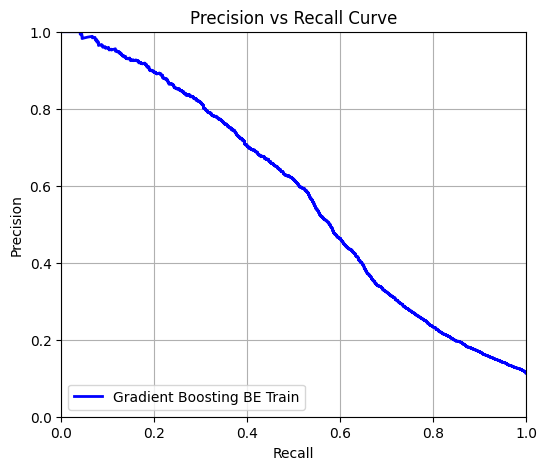

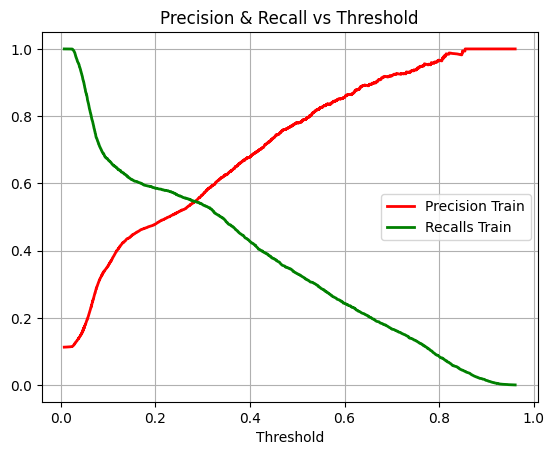

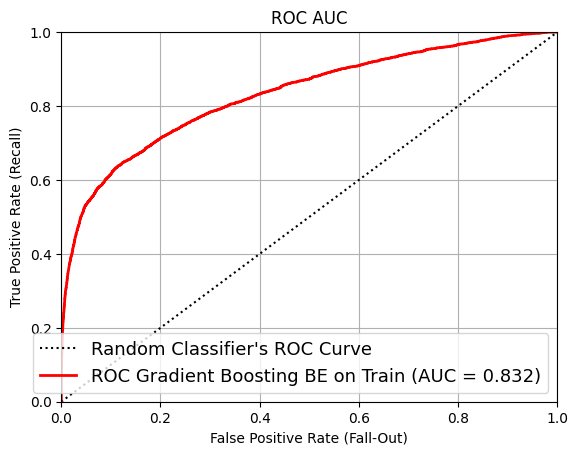

(0.7798223350253807,
 0.3310883620689655,
 0.46482602118003025,
 0.831518822524596)

In [82]:
#Evaluate the model on Train set
evaluateModel(y_train, y_train_proba_gb_be, "Gradient Boosting BE", "Train")

#### Evaluate Best Estimator on Test set

In [83]:
#predict probabilities, using the best estimator
y_test_proba_gb_be = gb_be.predict_proba(X_test)

#predict, using the best estimator
y_test_pred_gb_be = gb_be.predict(X_test)

Gradient Boosting BE Evaluation on Test set:
Precision: 0.661
Recall: 0.272
F1 Score: 0.385
AUC: 0.813


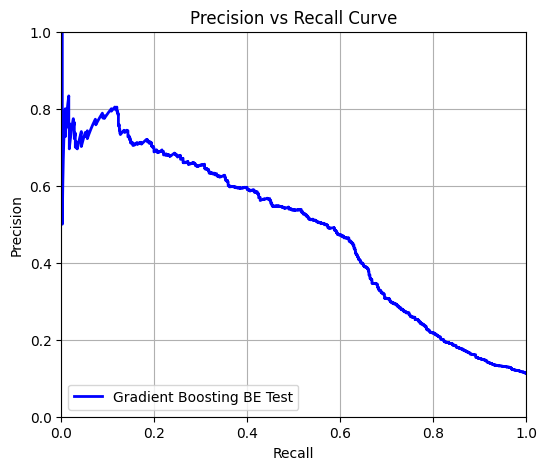

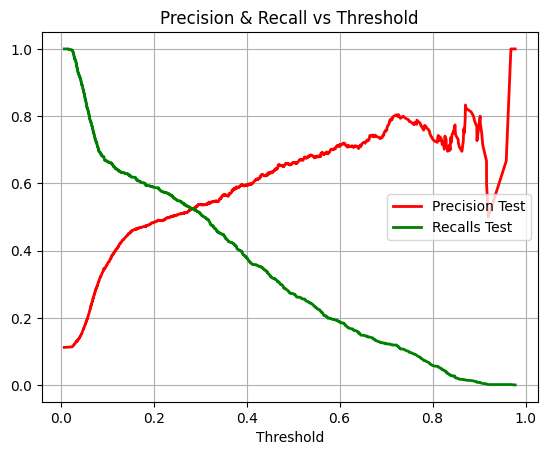

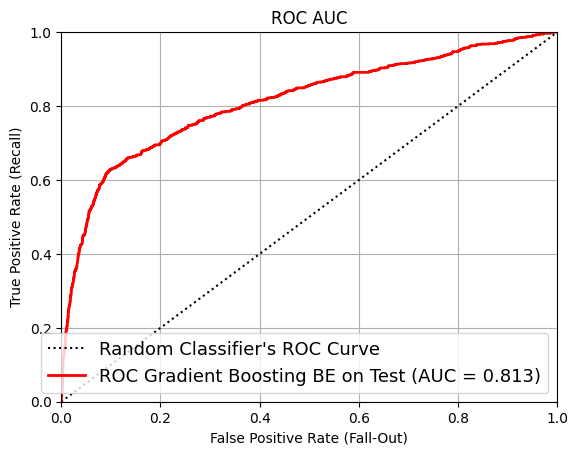

In [84]:
#Evaluate the model on Test set
gb_be_precision, gb_be_recall, gb_be_f1, gb_be_auc_score = evaluateModel(y_test, y_test_proba_gb_be, "Gradient Boosting BE", "Test")

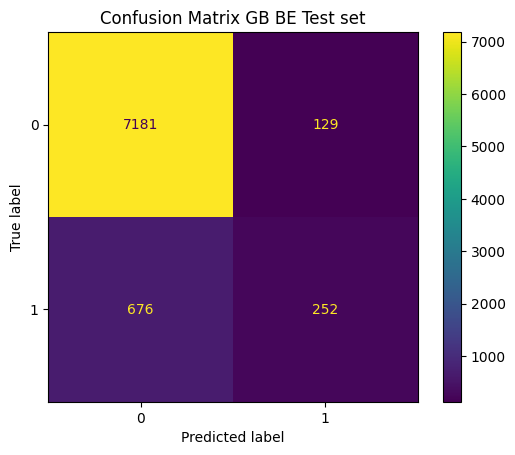

In [85]:
#Confusion Matrix Test set with best estimator
conf_matrix_be_gb = confusion_matrix(y_test, y_test_pred_gb_be)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_be_gb,
                              display_labels=gb_be.classes_)
disp.plot()
plt.title("Confusion Matrix GB BE Test set")
plt.show()

#### Conclusion of evaluation
- Using TRAIN set:
    - Curves & scores on basic model show that the model does not underfit or overfit
    - Curves & scores on cross validated model show that the model does not underfit or overfit
    - Curves & scores on best estimator (hyperparameter tuned) show that the model does not underfit or overfit
- Using TEST set 
    - Curves & scores on best estimator shouw that the model does not overfit or overfit
    
**--> Best Gradient Boosting model is usable**

### Costbased Thresholding GB

#### Calculation of Costs & Optimal threshold

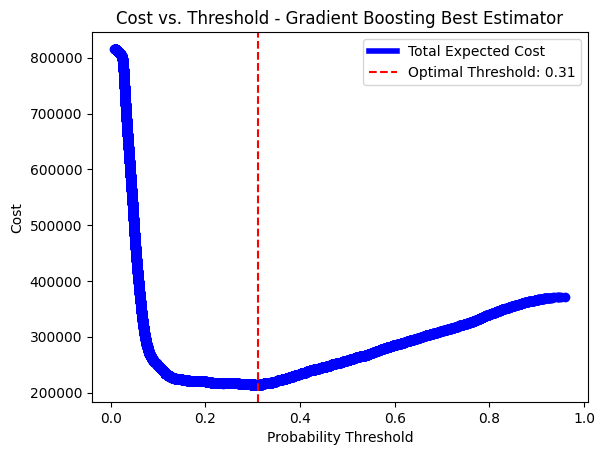

Optimal threshold for Gradient Boosting Best Estimator: 0.31
Precision: 0.58
Recall: 0.53
Empirically minimized expected costs: 213683.20
Empirically minimized expected costs per item: 6.49
 
With calibrated p threshold would be: 0.22
Expected cost with this calibrated p threshold: 217670.60


In [86]:
# use the TRAIN set to determine the optimal threshold
th_gb = empirical_costbased_thresholding(y_train, y_train_proba_gb_be[:,1], "Gradient Boosting Best Estimator", cost_unsuccesfull_call, cost_missed_call, p=True)

#### Average Cost

In [87]:
# use the TEST set and the TRAINED Threshold to determine average call cost.
y_pred_gb = (gb_be.predict_proba(X_test)[:,1]) > th_gb
av_testscore_gb = myAveragedCosts(y_test, y_pred_gb, cost_unsuccesfull_call, cost_missed_call)
print(f'Gradient Boosting Av Costs: €{av_testscore_gb:.2f}')

Gradient Boosting Av Costs: €7.00


# Comparison of Models

Used *TEST* for comparison of models (see p34 of book)
<br>
The cal

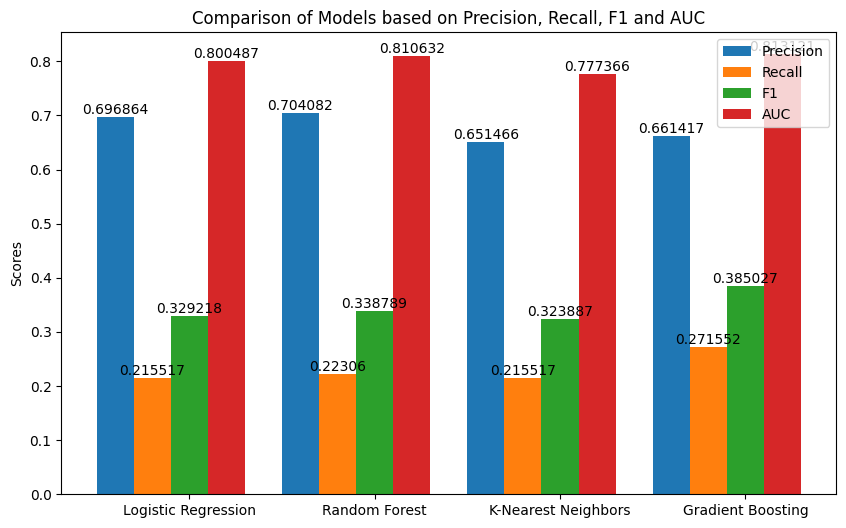

In [88]:
# Comparison of models based on Precision, Recall, F1 Score and AUC
models = ['Logistic Regression', 'Random Forest', 'K-Nearest Neighbors', 'Gradient Boosting']    

precision_scores = [lr_be_precision, rf_be_precision, knn_be_precision, gb_be_precision]
recall_scores = [lr_be_recall, rf_be_recall, knn_be_recall, gb_be_recall]
f1_scores = [lr_be_f1, rf_be_f1, knn_be_f1, gb_be_f1]
auc_scores = [lr_be_auc_score, rf_be_auc_score, knn_be_auc_score, gb_be_auc_score]

x = np.arange(len(models))  # the label locations
width = 0.2  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - 2*width, precision_scores, width, label='Precision')
ax.bar_label(rects1)
rects2 = ax.bar(x - width, recall_scores, width, label='Recall')
ax.bar_label(rects2)
rects3 = ax.bar(x, f1_scores, width, label='F1')
ax.bar_label(rects3)
rects4 = ax.bar(x + width, auc_scores, width, label='AUC')
ax.bar_label(rects4)

ax.set_ylabel('Scores')
ax.set_title('Comparison of Models based on Precision, Recall, F1 and AUC')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()



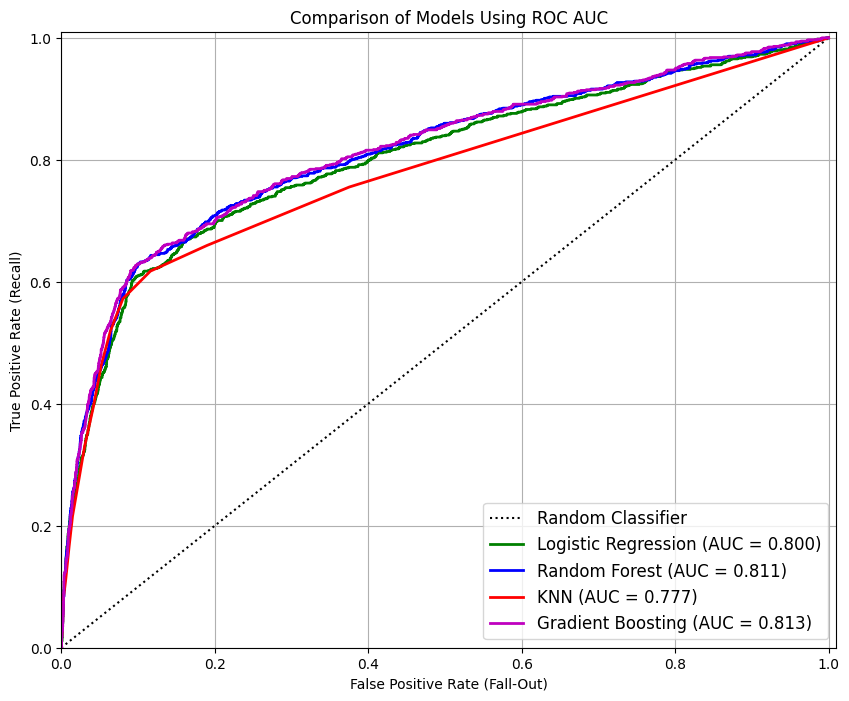

In [89]:
# TPR & FPR
fpr_lr_be, tpr_lr_be, _ = roc_curve(y_test, y_test_proba_lr_be[:, 1])
fpr_rf_be, tpr_rf_be, _ = roc_curve(y_test, y_test_proba_rf_be[:, 1])
fpr_knn_be, tpr_knn_be, _ = roc_curve(y_test, y_test_proba_knn_be[:, 1])
fpr_gb_be, tpr_gb_be, _ = roc_curve(y_test, y_test_proba_gb_be[:, 1])

# AUC scores
auc_lr_be = roc_auc_score(y_test, y_test_proba_lr_be[:, 1])
auc_rf_be = roc_auc_score(y_test, y_test_proba_rf_be[:, 1])
auc_knn_be = roc_auc_score(y_test, y_test_proba_knn_be[:, 1])
auc_gb_be = roc_auc_score(y_test, y_test_proba_gb_be[:, 1])

# Plot
plt.figure(figsize=(10, 8))

# Random classifier
plt.plot([0, 1], [0, 1], 'k:', label="Random Classifier")

# ROC curves
plt.plot(fpr_lr_be, tpr_lr_be, "g-", linewidth=2,
         label=f"Logistic Regression (AUC = {auc_lr_be:.3f})")

plt.plot(fpr_rf_be, tpr_rf_be, "b-", linewidth=2,
         label=f"Random Forest (AUC = {auc_rf_be:.3f})")

plt.plot(fpr_knn_be, tpr_knn_be, "r-", linewidth=2,
         label=f"KNN (AUC = {auc_knn_be:.3f})")

plt.plot(fpr_gb_be, tpr_gb_be, "m-", linewidth=2,
         label=f"Gradient Boosting (AUC = {auc_gb_be:.3f})")

# Formatting
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.title("Comparison of Models Using ROC AUC")
plt.grid(True)
plt.axis([0, 1.01, 0, 1.01])
plt.legend(loc="lower right", fontsize=12)
plt.show()


### Clean cost based tresholding for comparing models:

Cost-based thresholding was applied independently to each model by minimizing the expected misclassification cost over all possible decision thresholds, after which models were compared based on their minimum achievable cost.
- Computation without plotting and printing
- Functions should return only values
- One clean path that works for cost optimization + ROC

Results:
-  One function = one responsibility
-  Easy to compare models programmatically
-  Easy to plug into ROC
-  No hidden side effects (plots/prints)

In [ ]:
# define helper function

# Binary classification curve (TP, FP, FN at all thresholds)
def binary_clf_curve(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    order = np.argsort(y_score)[::-1]
    y_true = y_true[order]
    y_score = y_score[order]
    distinct_idx = np.where(np.diff(y_score))[0]
    threshold_idx = np.r_[distinct_idx, y_true.size - 1]
    tp = np.cumsum(y_true)[threshold_idx]
    fp = 1 + threshold_idx - tp
    fn = tp[-1] - tp
    thresholds = y_score[threshold_idx]
    return tp, fp, fn, thresholds

# Cost-based thresholding (TRAIN)
def cost_based_threshold(y_true, y_score, C_FP, C_FN):
    tp, fp, fn, thresholds = binary_clf_curve(y_true, y_score)
    costs = C_FP * fp + C_FN * fn
    idx = np.argmin(costs)
    return {
        "thresholds": thresholds,
        "costs": costs,
        "optimal_threshold": thresholds[idx],
        "min_cost": costs[idx],
        "tp": tp[idx],
        "fp": fp[idx],
        "fn": fn[idx],
        "precision": tp[idx]/(tp[idx]+fp[idx]),
        "recall": tp[idx]/(tp[idx]+fn[idx])
    }

# Apply threshold to predictions and compute average cost (TEST)
def average_cost(y_true, y_pred, C_FP, C_FN):
    cm = confusion_matrix(y_true, y_pred)
    fp = cm[0,1]
    fn = cm[1,0]
    return (C_FP*fp + C_FN*fn)/len(y_true)

# ROC point at threshold
def roc_point_at_threshold(y_true, y_score, threshold):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    idx = np.argmin(np.abs(thresholds - threshold))
    return fpr[idx], tpr[idx]

# Plot cost curve (optional)
def plot_cost_curve(thresholds, costs, optimal_threshold, model_name):
    plt.figure(figsize=(6,4))
    plt.plot(thresholds, costs, linewidth=2)
    plt.axvline(optimal_threshold, color='red', linestyle='--', 
                label=f'Optimal threshold = {optimal_threshold:.2f}')
    plt.xlabel("Probability threshold")
    plt.ylabel("Expected cost")
    plt.title(f"Cost vs Threshold — {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()



In [107]:
# Define models and their probabilities
models = {
    "Logistic Regression": y_train_proba_lr_be[:,1],
    "Random Forest": y_train_proba_rf_be[:,1],
    "KNN": y_train_proba_knn_be[:,1],
    "Gradient Boosting": y_train_proba_gb_be[:,1]
}

models_test_proba = {
    "Logistic Regression": y_test_proba_lr_be[:,1],
    "Random Forest": y_test_proba_rf_be[:,1],
    "KNN": y_test_proba_knn_be[:,1],
    "Gradient Boosting": y_test_proba_gb_be[:,1]
}


In [108]:
# Compute optimal tresholds on train and test performance
C_FP = cost_unsuccesfull_call
C_FN = cost_missed_call

results = {}

for name in models.keys():
    # Step 1: Optimal threshold on TRAIN
    train_result = cost_based_threshold(y_train, models[name], C_FP, C_FN)
    th_opt = train_result["optimal_threshold"]
    
    # Step 2: Apply threshold on TEST
    y_pred_test = models_test_proba[name] >= th_opt
    test_avg_cost = average_cost(y_test, y_pred_test, C_FP, C_FN)
    
    # Step 3: ROC AUC for TEST
    auc_test = roc_auc_score(y_test, models_test_proba[name])
    
    # Step 4: Store all results
    results[name] = {
        "train_result": train_result,
        "optimal_threshold": th_opt,
        "test_avg_cost": test_avg_cost,
        "auc_test": auc_test
    }

# Optional: display table
import pandas as pd
df_results = pd.DataFrame([
    {
        "Model": name,
        "Optimal Threshold": r["optimal_threshold"],
        "Train Cost": r["train_result"]["min_cost"],
        "Test Avg Cost": r["test_avg_cost"],
        "Test AUC": r["auc_test"],
        "Precision": r["train_result"]["precision"],
        "Recall": r["train_result"]["recall"]
    }
    for name, r in results.items()
])
df_results




,Model,Optimal Threshold,Train Cost,Test Avg Cost,Test AUC,Precision,Recall
0,Logistic Regression,0.190705,240170.2,6.826523,0.800487,0.420284,0.573815
1,Random Forest,0.322606,219961.9,7.348179,0.810632,0.567879,0.517241
2,KNN,0.250000,231121.8,6.807150,0.777366,0.453568,0.568427
3,Gradient Boosting,0.310226,213683.2,6.999272,0.813121,0.582938,0.530172


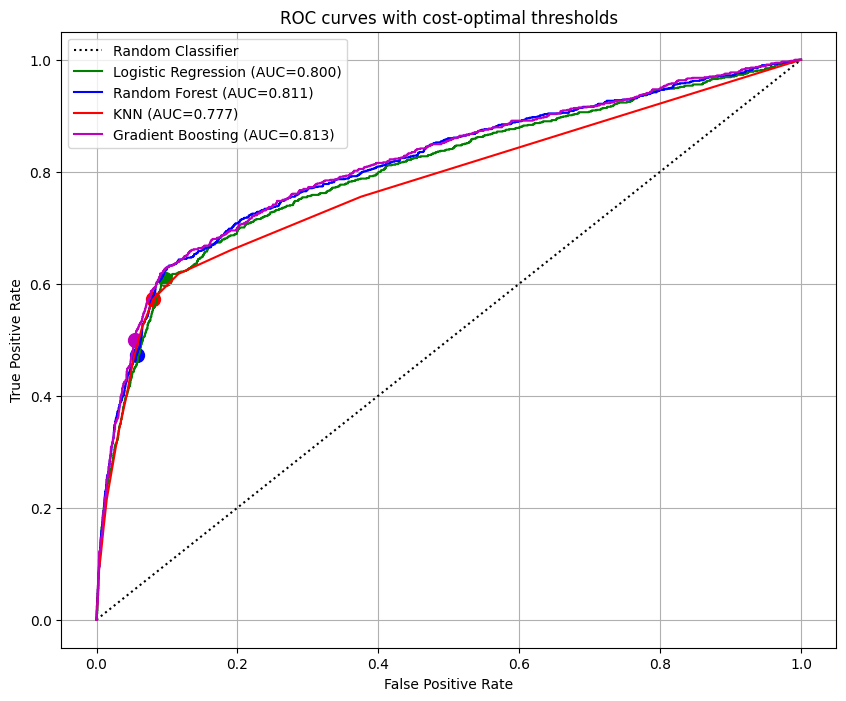

In [109]:
# Plot ROC curves with optimal points

plt.figure(figsize=(10,8))
plt.plot([0,1],[0,1],'k:', label='Random Classifier')

colors = ["g","b","r","m"]

for i, (name, r) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, models_test_proba[name])
    plt.plot(fpr, tpr, color=colors[i], label=f"{name} (AUC={r['auc_test']:.3f})")
    
    fpr_opt, tpr_opt = roc_point_at_threshold(y_test, models_test_proba[name], r["optimal_threshold"])
    plt.scatter(fpr_opt, tpr_opt, color=colors[i], s=100)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves with cost-optimal thresholds")
plt.grid(True)
plt.legend()
plt.show()



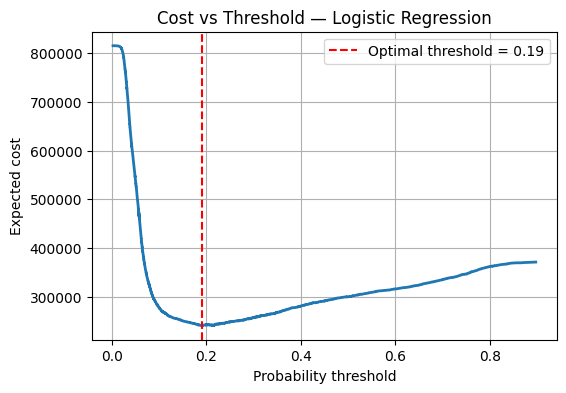

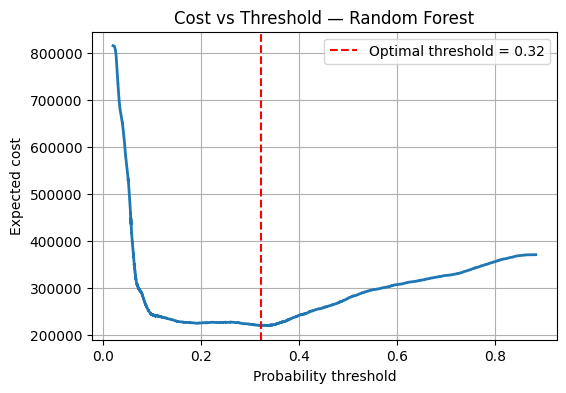

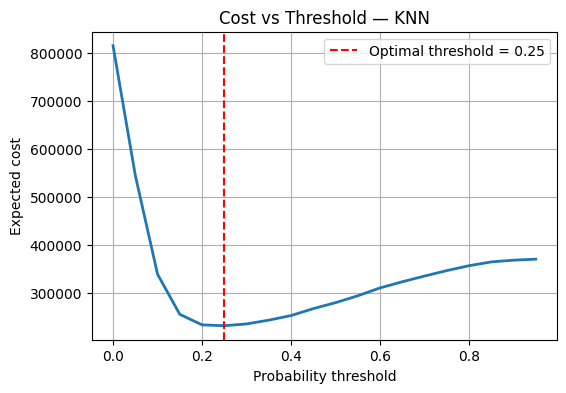

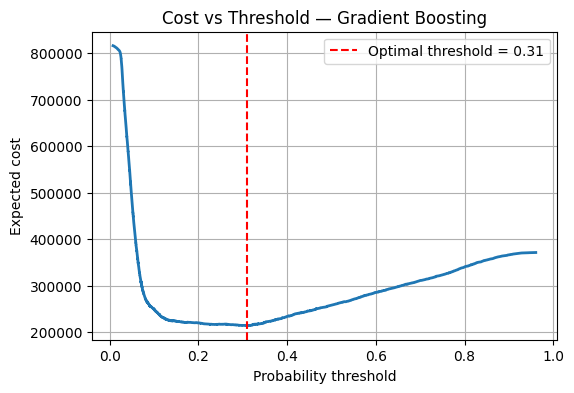

In [110]:
# Plot curves for all models
for name, r in results.items():
    plot_cost_curve(
        r["train_result"]["thresholds"],
        r["train_result"]["costs"],
        r["optimal_threshold"],
        name
    )


## Combining strenghts Rondom Forest and Gradient Boosting to get even better results
Why combining can help?

Random Forest:
Strenghts: Robust, low variance, handles noisy features
Weaknesses: Might underfit if individual trees are shallow	

Gradient Boosting:
Strenghts: Can achieve high accuracy, focuses on hard-to-predict cases
Weakness: Sensitive to noise/outliers, can overfit


Ensemble idea: Averaging predictions reduces variance. Sequential boosting reduces bias.

So if we combine them, we might reduce variance from Random Forest while keeping bias reduction from Gradient Boosting
We can potentially minimize cost even further if their errors are complementary.

Combining Random Forest and Gradient Boosting via soft voting, weighted averaging, or stacking is a valid approach. It can reduce costs and improve predictive performance by leveraging the complementary strengths of the two ensemble methods.

# Soft voting

In [111]:
# Combining with soft voting
y_pred_proba_combined = (y_test_proba_gb_be[:,1] + y_test_proba_rf_be[:,1]) / 2

In [ ]:
# Use your existing cost-based threshold function to find the optimal threshold on train set:
combined_train_proba = (y_train_proba_gb_be[:,1] + y_train_proba_rf_be[:,1])/2
combined_result = cost_based_threshold(y_train, combined_train_proba, C_FP, C_FN)
th_combined = combined_result["optimal_threshold"]


In [113]:
# Apply treshold on test set:
combined_test_proba = (y_test_proba_gb_be[:,1] + y_test_proba_rf_be[:,1])/2
y_pred_combined = combined_test_proba >= th_combined
combined_test_cost = average_cost(y_test, y_pred_combined, C_FP, C_FN)


In [115]:
# Gradient Boosting 
gb_result = cost_based_threshold(
    y_train, y_train_proba_gb_be[:, 1], C_FP, C_FN
)
th_gb = gb_result["optimal_threshold"]

y_pred_gb = y_test_proba_gb_be[:, 1] >= th_gb
gb_test_cost = average_cost(y_test, y_pred_gb, C_FP, C_FN)


# Random Forest
rf_result = cost_based_threshold(
    y_train, y_train_proba_rf_be[:, 1], C_FP, C_FN
)
th_rf = rf_result["optimal_threshold"]

y_pred_rf = y_test_proba_rf_be[:, 1] >= th_rf
rf_test_cost = average_cost(y_test, y_pred_rf, C_FP, C_FN)


# Combined (GB + RF)
combined_train_proba = (
    y_train_proba_gb_be[:, 1] + y_train_proba_rf_be[:, 1]
) / 2

combined_test_proba = (
    y_test_proba_gb_be[:, 1] + y_test_proba_rf_be[:, 1]
) / 2

combined_result = cost_based_threshold(
    y_train, combined_train_proba, C_FP, C_FN
)
th_combined = combined_result["optimal_threshold"]

y_pred_combined = combined_test_proba >= th_combined
combined_test_cost = average_cost(y_test, y_pred_combined, C_FP, C_FN)


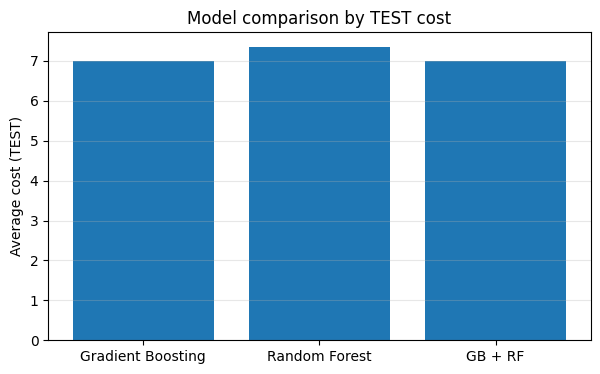

In [116]:
models = ["Gradient Boosting", "Random Forest", "GB + RF"]
costs = [gb_test_cost, rf_test_cost, combined_test_cost]

plt.figure(figsize=(7,4))
plt.bar(models, costs)
plt.ylabel("Average cost (TEST)")
plt.title("Model comparison by TEST cost")
plt.grid(axis="y", alpha=0.3)
plt.show()


There seems to be improvement in combing GB and RF with soft voting. Now let's try a weighted combination.

In [130]:
# Sweep weights to find the best one
weights = np.linspace(0, 1, 11)  # 0.0, 0.1, 0.2 ... 1.0
train_costs = []

for w in weights:
    combined_train_proba = w * y_train_proba_gb_be[:,1] + (1-w) * y_train_proba_rf_be[:,1]
    result = cost_based_threshold(y_train, combined_train_proba, C_FP, C_FN)
    train_costs.append(result["min_cost"])

# Find weight with minimum TRAIN cost
best_idx = np.argmin(train_costs)
best_w = weights[best_idx]

print(f"Best weight for GB: {best_w:.2f}, RF: {1-best_w:.2f}")
print(f"Minimum TRAIN cost: {train_costs[best_idx]:.2f}")


Best weight for GB: 0.90, RF: 0.10
Minimum TRAIN cost: 213392.30


In [132]:
# Compute optimal threshold for this weight
combined_train_proba = best_w * y_train_proba_gb_be[:,1] + (1-best_w) * y_train_proba_rf_be[:,1]
combined_test_proba  = best_w * y_test_proba_gb_be[:,1] + (1-best_w) * y_test_proba_rf_be[:,1]

combined_result = cost_based_threshold(y_train, combined_train_proba, C_FP, C_FN)
th_combined = combined_result["optimal_threshold"]

print(f"Optimal threshold for weighted model: {th_combined:.3f}")


Optimal threshold for weighted model: 0.309


In [133]:
# Evaluate TEST cost
y_pred_combined = combined_test_proba >= th_combined
combined_test_cost = average_cost(y_test, y_pred_combined, C_FP, C_FN)

print(f"Weighted combined model TEST cost: €{combined_test_cost:.2f}")


Weighted combined model TEST cost: €6.98


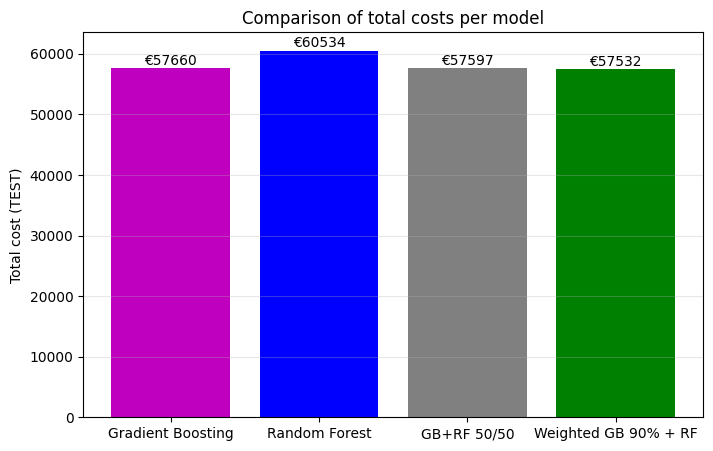

In [140]:
# Comparison of total costs

# GB
y_pred_gb = y_test_proba_gb_be[:,1] >= th_gb
gb_total_cost = (C_FP * np.sum((y_pred_gb==1) & (y_test==0)) +
                 C_FN * np.sum((y_pred_gb==0) & (y_test==1)))

# RF
y_pred_rf = y_test_proba_rf_be[:,1] >= th_rf
rf_total_cost = (C_FP * np.sum((y_pred_rf==1) & (y_test==0)) +
                 C_FN * np.sum((y_pred_rf==0) & (y_test==1)))

# GB+RF 50/50
combined_5050_train = (y_train_proba_gb_be[:,1] + y_train_proba_rf_be[:,1])/2
combined_5050_test = (y_test_proba_gb_be[:,1] + y_test_proba_rf_be[:,1])/2
th_5050 = cost_based_threshold(y_train, combined_5050_train, C_FP, C_FN)["optimal_threshold"]
y_pred_5050 = combined_5050_test >= th_5050
combined_5050_total_cost = (C_FP * np.sum((y_pred_5050==1) & (y_test==0)) +
                            C_FN * np.sum((y_pred_5050==0) & (y_test==1)))

# Weighted combination
y_pred_weighted = combined_test_proba >= th_combined
weighted_total_cost = (C_FP * np.sum((y_pred_weighted==1) & (y_test==0)) +
                       C_FN * np.sum((y_pred_weighted==0) & (y_test==1)))

# Bar plot total costs
models = ["Gradient Boosting", "Random Forest", "GB+RF 50/50", f"Weighted GB {int(best_w*100)}% + RF"]
total_costs = [gb_total_cost, rf_total_cost, combined_5050_total_cost, weighted_total_cost]

plt.figure(figsize=(8,5))
bars = plt.bar(models, total_costs, color=["m","b","gray","g"])
plt.ylabel("Total cost (TEST)")
plt.title("Comparison of total costs per model")
plt.grid(axis="y", alpha=0.3)

# Add labels on bars
for bar, cost in zip(bars, total_costs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f"€{int(cost)}",
             ha='center', va='bottom', fontsize=10)

plt.show()



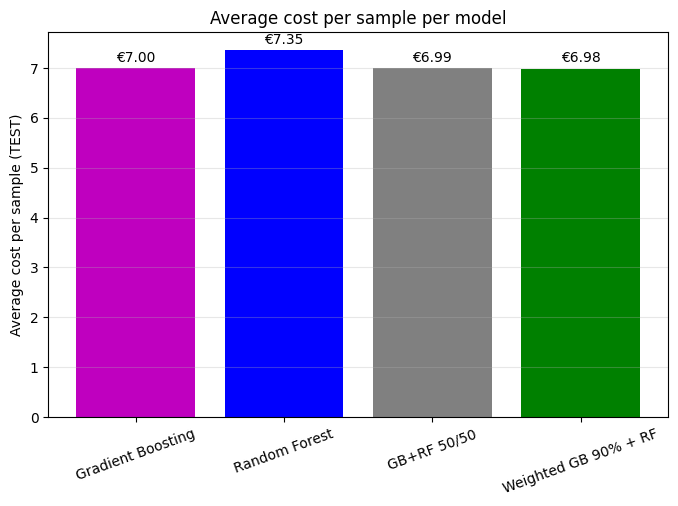

In [143]:
# Compute average cost per sample
avg_costs = [cost / len(y_test) for cost in total_costs]

# Bar plot average costs
plt.figure(figsize=(8,5))
bars = plt.bar(models, avg_costs, color=["m","b","gray","g"])
plt.ylabel("Average cost per sample (TEST)")
plt.title("Average cost per sample per model")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20)  # optional, if labels are long

# Add labels **just above the bars**
for bar, cost in zip(bars, avg_costs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01, f"€{cost:.2f}",
             ha='center', va='bottom', fontsize=10)

plt.show()

# Compare metrics

In [144]:
# Helper function
def compute_metrics(y_true, y_pred, y_proba):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    return precision, recall, f1, auc

# ---- Gradient Boosting ----
y_pred_gb = y_test_proba_gb_be[:,1] >= th_gb
metrics_gb = compute_metrics(y_test, y_pred_gb, y_test_proba_gb_be[:,1])

# ---- Random Forest ----
y_pred_rf = y_test_proba_rf_be[:,1] >= th_rf
metrics_rf = compute_metrics(y_test, y_pred_rf, y_test_proba_rf_be[:,1])

# ---- GB + RF 50/50 ----
y_pred_5050 = combined_5050_test >= th_5050
metrics_5050 = compute_metrics(y_test, y_pred_5050, combined_5050_test)

# ---- Weighted GB + RF ----
y_pred_weighted = combined_test_proba >= th_combined
metrics_weighted = compute_metrics(y_test, y_pred_weighted, combined_test_proba)


In [145]:
import pandas as pd

df_metrics = pd.DataFrame({
    "Model": ["Gradient Boosting", "Random Forest", "GB+RF 50/50", f"Weighted GB {int(best_w*100)}% + RF"],
    "Precision": [metrics_gb[0], metrics_rf[0], metrics_5050[0], metrics_weighted[0]],
    "Recall":    [metrics_gb[1], metrics_rf[1], metrics_5050[1], metrics_weighted[1]],
    "F1":        [metrics_gb[2], metrics_rf[2], metrics_5050[2], metrics_weighted[2]],
    "AUC":       [metrics_gb[3], metrics_rf[3], metrics_5050[3], metrics_weighted[3]]
})

df_metrics = df_metrics.round(3)
df_metrics


,Model,Precision,Recall,F1,AUC
0,Gradient Boosting,0.537,0.499,0.517,0.813
1,Random Forest,0.513,0.473,0.492,0.811
2,GB+RF 50/50,0.523,0.509,0.516,0.814
3,Weighted GB 90% + RF,0.538,0.500,0.518,0.814


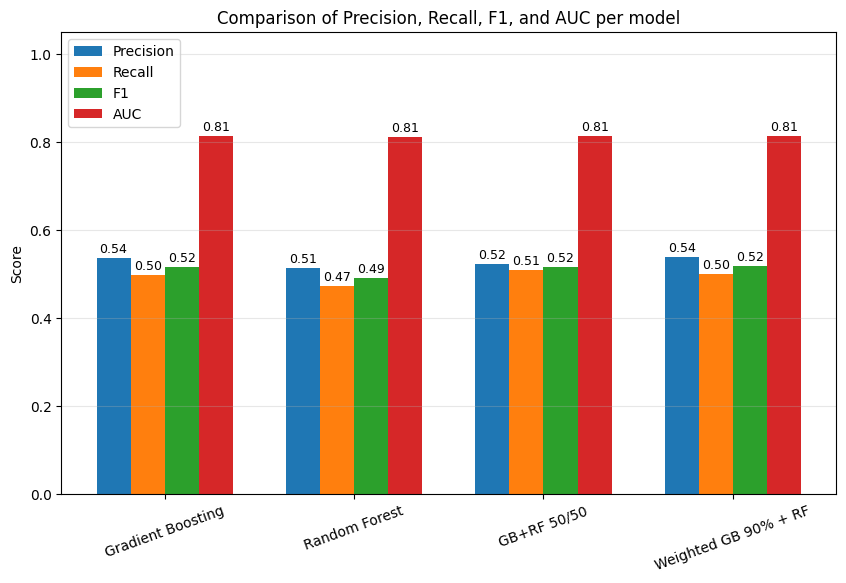

In [147]:
# plot barchart
metrics = ["Precision", "Recall", "F1", "AUC"]
n_metrics = len(metrics)
n_models = len(df_metrics)

# Bar width and positions
bar_width = 0.18
x = np.arange(n_models)  # position of models on x-axis

plt.figure(figsize=(10,6))

# Plot each metric
for i, metric in enumerate(metrics):
    plt.bar(x + i*bar_width, df_metrics[metric], width=bar_width, label=metric)

    # Add labels on top of each bar
    for j in range(n_models):
        plt.text(x[j] + i*bar_width, df_metrics[metric][j] + 0.005, 
                 f"{df_metrics[metric][j]:.2f}", ha='center', va='bottom', fontsize=9)

# X-axis labels and title
plt.xticks(x + bar_width*(n_metrics-1)/2, df_metrics["Model"], rotation=20)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Comparison of Precision, Recall, F1, and AUC per model")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()
